# YOLOの進化を動かして理解する

## 全体概要

YOLOは **画像全体を一度に見て物体の位置と種類を予測する one-stage detector** として始まりました。ただし、v1から現在までを管理する単一組織はありません。v5以降の番号は異なるチームが提案した系列を含むため、番号が大きいだけで常に同じ設計の直接後継、または全用途で優秀、という意味ではありません。

本教材は番号付きの主要リリースを v1→v13 の順に比較し、途中で番号付きではない重要な派生として YOLOX、YOLO-NAS、RT-DETR も時系列順に扱い、最後に Ultralytics の現行製品系列 YOLO26 を扱います。**v14〜v25という公開版があるわけではなく、YOLO26は年に合わせた命名**です。

### 学び方

1. 各節の詳細説明で、検出の考え方がどう変わったかを読む
2. NumPyだけの小規模デモで、その変化を最小例として観察する
3. 対応する公式実装・重みで実画像推論を行い、複数画像で結果を比較する

小規模デモは本物のネットワーク精度を再現するものではなく、差分となる演算・データ表現を分離して観察する教材です。精度や速度の数値比較には、同じデータ、解像度、ハードウェア、測定条件が必要です。

In [1]:
from pathlib import Path
import sys, json

ROOT = Path.cwd()
if not (ROOT / 'common').exists():
    raise RuntimeError('このノートブックをリポジトリ直下から実行してください')
sys.path.insert(0, str(ROOT))

from common.versions import VERSIONS
from common.demos import run_demo
from common.runner import main as run_yolo
from common.notebook_helpers import reload_tutorial_helpers
from common.related_tech import *
from common.yolo_demo import *
from common.visualization import *

# ヘルパを編集中に変更を反映したい場合だけ実行します。
reload_tutorial_helpers(globals())


print('収録:', ', '.join(VERSIONS[v]['title'] for v in VERSIONS))


収録: YOLOv1, YOLOv2 / YOLO9000, YOLOv3, YOLOv4, YOLOv5, YOLOv6, YOLOv7, YOLOv8, YOLOv9, YOLOv10, YOLO11, YOLOv12, YOLOv13, YOLO26 (Ultralytics product line)


## 推論環境

技術デモのみ: `python -m pip install -r requirements-demo.txt`

画像推論も行う: `python -m pip install -r requirements.txt`

- v1〜v4: Darknet形式の `.cfg` と `.weights` を用意し、OpenCV DNNで実行
- v5/v8〜v12/YOLO26: `ultralytics` が読める対応 `.pt` を指定
- YOLOX/YOLO-NAS/RT-DETR/v6/v7/v13: 公式リポジトリごとに環境が異なるので、その推論コマンドを `--command` 経由で実行

この教材の実行入口は `common.runner.main` です。ノートブックでは `run_yolo(version, args)` として直接呼び出します。番号付きモデルは `run_yolo(8, ...)` のように指定し、YOLOX、YOLO-NAS、RT-DETRは `run_yolo("yolox", ...)`、`run_yolo("yolo-nas", ...)`、`run_yolo("rt-detr", ...)` のように文字列キーで指定します。

## 関連技術

YOLOの各世代そのものではありませんが、物体検出を理解・実装・比較するときに必要になる周辺技術をここに整理します。たとえば評価指標、データ拡張、バックボーン、特徴ピラミッド、NMS、モデル圧縮、量子化、ONNX/TensorRT、アノテーション形式などは、このセクションに説明を追加していきます。

### Leaky ReLU

Leaky ReLUは、ReLUの負の領域を完全に0にせず、小さな傾きで通す活性化関数です。

$$
f(x) =
\begin{cases}
x & (x > 0) \\
\alpha x & (x \le 0)
\end{cases}
$$

通常のReLUでは、入力が負のとき出力も勾配も0になります。一方、Leaky ReLUでは負の側にも `alpha` 倍の小さな勾配が残ります。

YOLOv1では多くの層でLeaky ReLUを使います。負の側にも勾配が残るため、ユニットが完全に更新されなくなる問題を少し避けやすくなります。


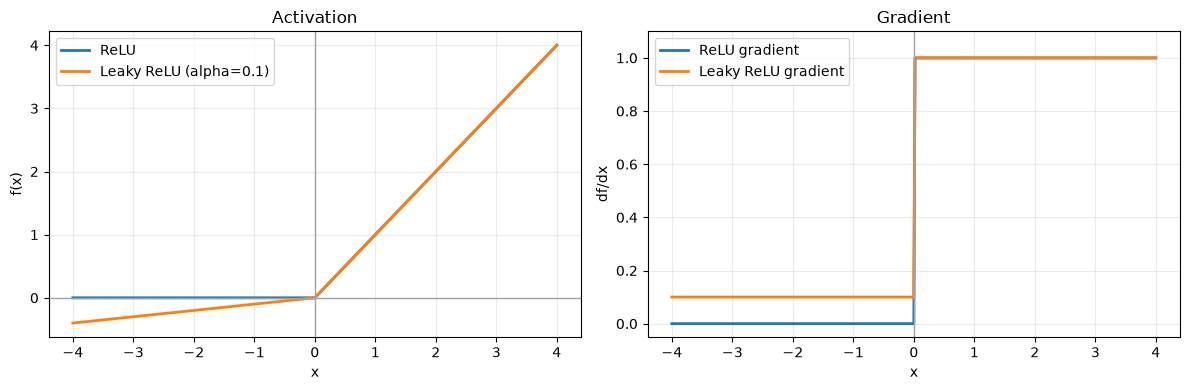

In [19]:
display_leaky_relu_demo(alpha=0.1)

### Darknet形式

Darknetは、初期YOLOの作者が使っていたC実装の深層学習フレームワークです。YOLOv1〜v4系の古いモデルでは、PyTorchの `.pt` ではなく、主に次の2つのファイルを組み合わせて推論します。

- `.cfg`: ネットワーク構造を表すテキストファイルです。層の種類、filter数、anchor、class数、入力サイズなどが入ります。
- `.weights`: 学習済み重みを入れたバイナリファイルです。畳み込みカーネル、bias、BatchNorm統計量などが入ります。

つまり、`.cfg` が「どんなネットワークか」、`.weights` が「学習済みパラメータはいくつか」を持ちます。OpenCV DNNなどでDarknet形式を読むときも、この2つを合わせてモデルを復元します。


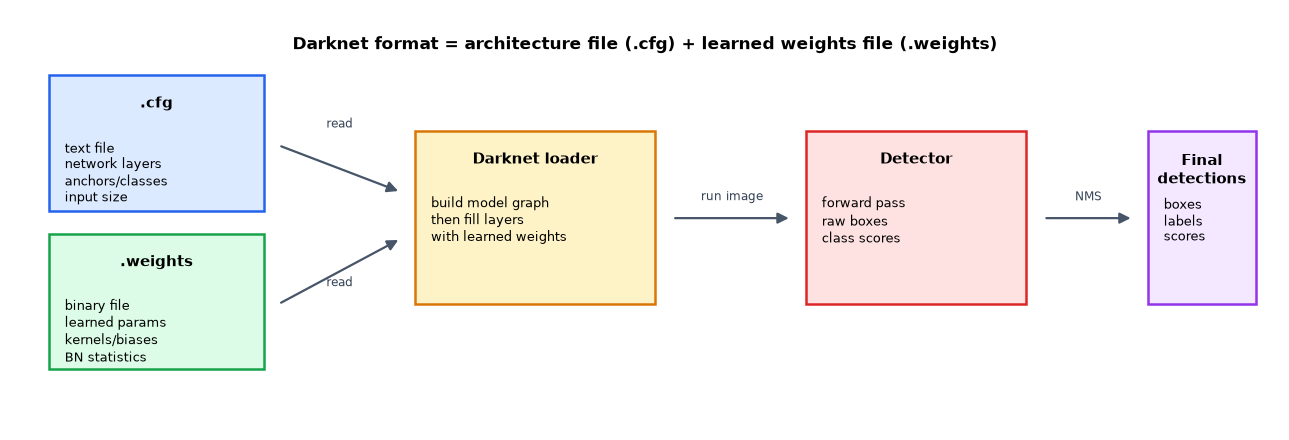

In [22]:
darknet_file_roles()
display_darknet_format_demo()

### NMS

NMS（Non-Maximum Suppression）は、同じ物体に対して重複したbbox候補が複数出たときに、スコアが高いbboxだけを残す後処理です。

基本的なアルゴリズムは次の通りです。

1. bbox候補をconfidenceやclass scoreで高い順に並べる。
2. もっともスコアが高いbboxを採用する。
3. 採用したbboxとIoUが高い他のbboxを削除する。
4. 残ったbboxに対して同じ処理を繰り返す。

YOLOv1でも、最終的な検出結果を整理するためにNMSを使います。モデル本体がbbox候補を出し、NMSが重複候補を整理する、という役割分担です。


{'keep': 'A', 'comparisons': [{'with': 'B', 'iou': 0.7102272727272725, 'suppressed': True}, {'with': 'C', 'iou': 0.03365384615384605, 'suppressed': False}, {'with': 'D', 'iou': 0.0, 'suppressed': False}]}
{'keep': 'C', 'comparisons': [{'with': 'D', 'iou': 0.7317073170731707, 'suppressed': True}]}


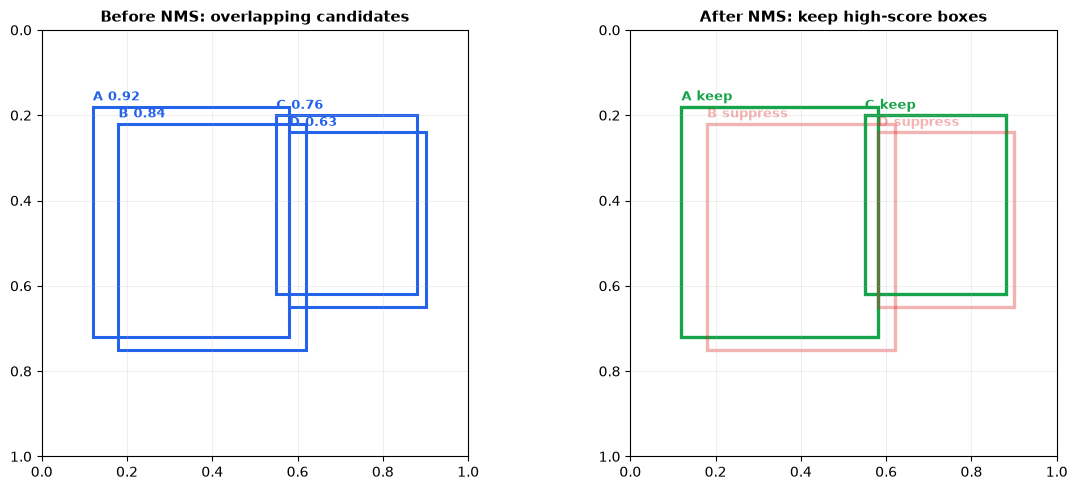

In [23]:
nms_result = run_nms_demo(iou_threshold=0.5)
for step in nms_result['steps']:
    print(step)
display_nms_demo(nms_result)

### ONNX / TensorRT / OpenVINO / CoreML

YOLOv5以降の実務パイプラインでは、学習した `.pt` などの重みをそのまま使うだけでなく、配備先に合わせて別の形式へexportすることが多くなります。ここで出てくる代表的な名前が ONNX、TensorRT、OpenVINO、CoreML です。これらは新しいYOLOアーキテクチャそのものではなく、**学習済みモデルをどの環境で速く安定して動かすか**に関係する技術です。

まず ONNX は、PyTorch、TensorFlow などの違いを越えてモデル構造を受け渡すための中間形式です。PyTorchで学習したモデルをONNXへexportすると、別の推論エンジンや最適化ツールへ渡しやすくなります。ONNX自体は特定GPU向けの最速実行エンジンというより、モデル交換のための共通表現として理解するとよいです。

```text
PyTorch weights.pt
  -> ONNX model.onnx
  -> TensorRT / OpenVINO / CoreML / ONNX Runtime など
```

TensorRT は NVIDIA GPU 向けの推論最適化エンジンです。ONNXなどから読み込んだモデルを、NVIDIA GPUで速く動くようにlayer fusion、precision変更、kernel選択などで最適化します。たとえばFP32からFP16やINT8へ落とすことで、精度と速度のトレードオフを取りながら低遅延化します。

OpenVINO は Intel 系のCPU、iGPU、NPUなどで推論を最適化するためのツールキットです。GPUサーバではなく、Intel CPU搭載PCやエッジ端末でYOLOを動かしたい場合に候補になります。TensorRTがNVIDIA GPU寄りなのに対して、OpenVINOはIntel系ハードウェアでの推論最適化に強い、と見ると分かりやすいです。

CoreML は Apple の推論形式・フレームワークです。iPhone、iPad、Mac など Apple 環境でモデルを動かすために使います。アプリ内でカメラ画像に対して物体検出を行う場合など、Apple端末上での実行を考えるとCoreMLへの変換が重要になります。

整理すると次のようになります。

| 名前 | 主な役割 | 主な対象 |
|---|---|---|
| ONNX | モデル交換用の中間形式 | 複数フレームワーク・複数推論エンジン |
| TensorRT | NVIDIA GPU向け高速推論 | NVIDIA GPU / Jetson |
| OpenVINO | Intel系ハードウェア向け高速推論 | Intel CPU / iGPU / NPU |
| CoreML | Apple端末向け推論 | iPhone / iPad / Mac |

重要なのは、export後に必ず同じ結果・同じ速度になるわけではないことです。演算子の対応、入力サイズ、NMSなどの後処理をどこまで含めるか、FP16/INT8量子化を使うかによって、速度・精度・実装の複雑さが変わります。そのため世代比較や配備判断では、mAPだけでなく、target hardware上の実測レイテンシと変換後の出力一致も確認する必要があります。


## YOLOv1 (2016)

**新しく加わった技術:** 画像全体を1回のCNNで処理し、グリッドごとにbboxとクラスを同時回帰。

ここでは、YOLOv1で重要だった3つの要素を順番に実装して、データがどう変化するかを確認します。実際のYOLOv1の重みを再現するのではなく、手元の画像と正規化bboxを使って、YOLOv1の出力表現を小さく作ります。

1. **画像全体を1回で処理:** 画像全体を入力として、`S x S x (B*5+C)` の出力テンソルを一度に作る。
2. **グリッド責任セル:** 物体中心が入ったセルを、その物体の担当セルにする。
3. **bboxとクラスの同時回帰:** 担当セルに `[x_cell, y_cell, w, h, confidence]` とclass確率を同時に埋め込む。

**注意:** この節のデモはYOLOv1の表現形式を理解するための教材です。モデル全体の再実装や学習済み重みの再現ではありません。

出典: [公式/著者実装](https://github.com/pjreddie/darknet) / [論文](https://arxiv.org/abs/1506.02640)


### YOLOv1のアーキテクチャ全体像

YOLOv1は、画像全体を1つのCNNに入れ、最後に `S x S x (B * 5 + C)` のテンソルを出力するone-stage detectorです。ネットワークは大まかに **24個の畳み込み層と2個の全結合層** からなり、多くの層でLeaky ReLUを使います。**グリッドごとに別々のCNNを走らせるのではなく、画像全体に対して1つのCNNを1回だけ実行し、その出力を `S x S` 個のセルとして解釈します。** 候補領域を先に作るtwo-stage detectorとも違い、1回のforwardで「どこに物体があるか」と「それが何か」を同時に出します。

下の図は、YOLOv1論文のFig.3のように、入力から出力までの層の並びを簡略化して描いたものです。処理の流れは次の通りです。

1. **入力画像を固定サイズにリサイズする**  
   論文では画像を `448 x 448` にリサイズしてCNNへ入れます。

2. **CNNで画像全体の特徴を抽出する**  
   畳み込み層で画像全体の特徴を作り、最後に全結合層で検出用の出力テンソルへ変換します。この時点で全グリッドセル分の予測がまとめて作られます。全結合層にはDropoutも使われます。

3. **ImageNet分類事前学習から検出fine-tuningへ移る**  
   YOLOv1は、まずImageNetで分類モデルとして事前学習し、その後に検出タスクへfine-tuningします。これは学習戦略として非常に重要です。最初から少ない検出データだけで学習するのではなく、分類で得た一般的な画像特徴を検出へ転用します。

4. **画像を `S x S` グリッドとして扱う**  
   YOLOv1では典型的に `S=7` なので、画像を `7 x 7` の49セルに分けます。物体の中心が入ったセルが、その物体の予測を担当します。

5. **各セルがbbox候補とclass確率を出す**  
   各セルは `B` 個のbbox候補を出します。各bbox候補は `x, y, w, h, confidence` を持ちます。さらに、そのセルごとにclass確率 `C` 個を出します。

6. **bbox・confidence・classを同じlossで同時に学習する**  
   bbox座標、object confidence、no-object confidence、class確率を、maskと重み付きのMSEでまとめて最適化します。

7. **推論時はconfidenceとclass確率から最終スコアを作る**  
   各bboxのconfidenceとclass確率を組み合わせ、閾値処理やNMSで最終的な検出結果を残します。

この図で重要なのは、`7 x 7` の各セルが別々のCNNで計算されるのではなく、最後の出力テンソルをセルごとに解釈している点です。この後の3つのサブセクションでは、この全体像のうち、YOLOv1の核になる「1回の出力テンソル」「グリッド責任セル」「bboxとclassの同時学習」を順番に小さく実装して確認します。


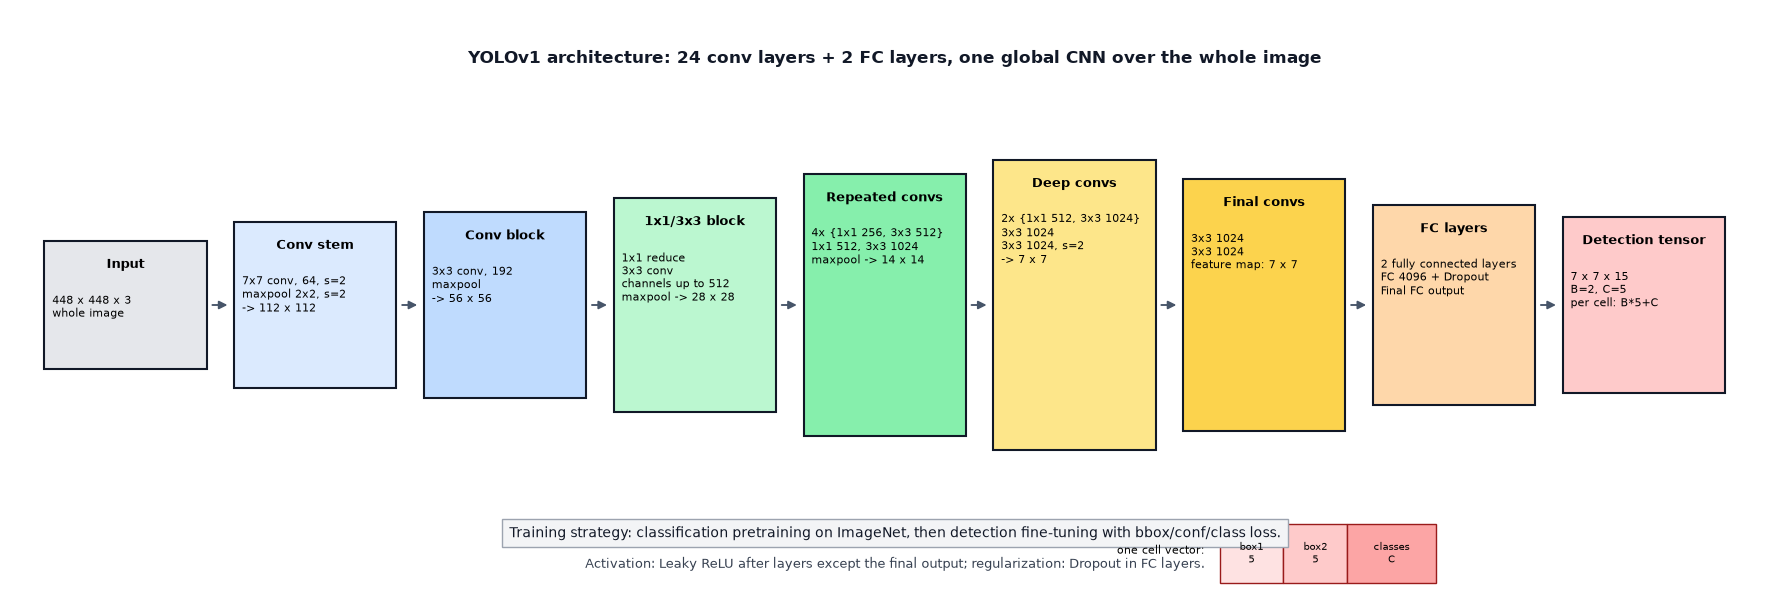

In [24]:
v1_stages = build_yolov1_stages('images/sample.jpg')
display_yolov1_architecture(v1_stages)

### 1. 入力画像1枚から、出力テンソル全体を1回で得る

このサブセクションで確認したいことは、**YOLOv1は入力画像1枚に対して、画像全体の検出結果を入れるための大きな出力テンソルを1回で返す**という点です。ここでは実物のCNNは動かさず、YOLOv1が返すはずの出力の「形」と「各場所の意味」を小さく再現します。

YOLOv1の出力形状は次のように表します。

```text
S x S x (B * 5 + C)
```

それぞれの意味は次の通りです。

- `S`: 画像を縦横に何分割するか。YOLOv1では典型的に `S=7` なので、画像を `7 x 7 = 49` 個のセルに分けます。
- `B`: 1つのセルが出せるbbox候補の数。ここでは `B=2` なので、各セルはbbox候補を2個持ちます。
- `5`: bbox候補1個あたりの値の数です。内訳は `x`, `y`, `w`, `h`, `confidence` の5つです。
- `C`: クラス数です。ここではデモを小さくするため、`person`, `bicycle`, `motorcycle`, `car`, `bus` の5クラスだけを使うので `C=5` です。

したがって、このデモでは1つのセルが持つ値の数は次のようになります。

```text
B * 5 + C = 2 * 5 + 5 = 15
```

つまり出力全体は次の形です。

```text
7 x 7 x 15
```

これは「49個のセルそれぞれに、bbox候補2個分の情報と、5クラス分の確率が入る」という意味です。重要なのは、物体ごとに画像を切り出して何度も分類するのではなく、**画像全体を1回処理して、この `7 x 7 x 15` 全体をまとめて得る**という点です。


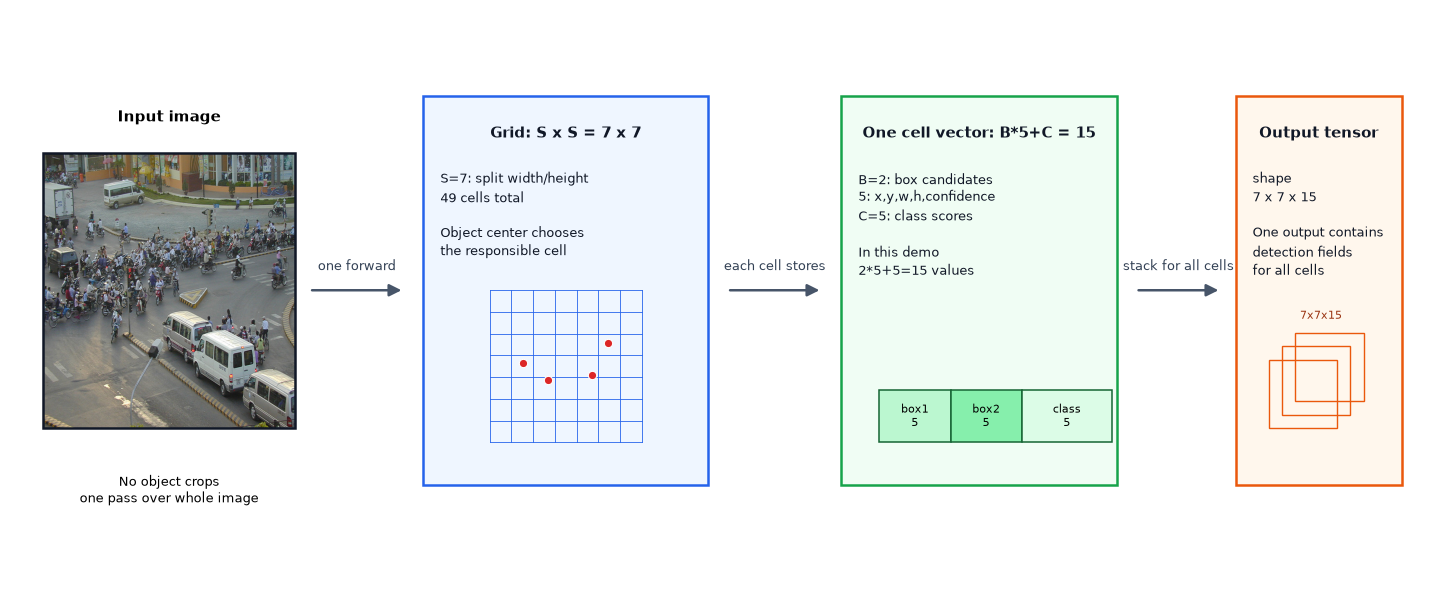

In [25]:
v1_stages = build_yolov1_stages('images/sample.jpg')
display_yolov1_output_flow(v1_stages)

### 2. グリッド責任セルを決める

ここでいう「物体中心」は、**学習時にはアノテーション済みの正解bboxから計算する中心点**です。つまり、YOLOv1が最初に中心点を見つけてから担当セルを決めるわけではありません。

学習時の流れは次の通りです。

1. 正解bbox `x1, y1, x2, y2` から中心点 `(cx, cy)` を計算する。
2. その中心点が入っているgrid cellを、その物体の担当セルにする。
3. その担当セルだけに、その物体のbboxとclassを予測するように教師信号を入れる。

推論時には正解bboxはありません。その代わり、学習によって各セルは「自分のセル内に中心がある物体」を予測するようになります。各セルは `x_cell, y_cell` を出力しますが、これは画像全体での中心点ではなく、**そのセルの左上を基準にしたセル内相対座標**です。

したがって、このサブセクションで行っている処理は「中心点を予測する処理」ではなく、**正解bboxから担当セルを作り、YOLOv1がどのセルにどの物体を学習させるかを決める処理**です。


person     center=[0.22, 0.48] -> cell(row, col)=[3, 1] offset_in_cell=[0.54, 0.3599999999999999] encoded=True
motorcycle center=[0.38, 0.59] -> cell(row, col)=[4, 2] offset_in_cell=[0.6600000000000001, 0.1299999999999999] encoded=True
bicycle    center=[0.675, 0.56] -> cell(row, col)=[3, 4] offset_in_cell=[0.7250000000000005, 0.9200000000000004] encoded=True
car        center=[0.78, 0.35] -> cell(row, col)=[2, 5] offset_in_cell=[0.45999999999999996, 0.44999999999999973] encoded=True


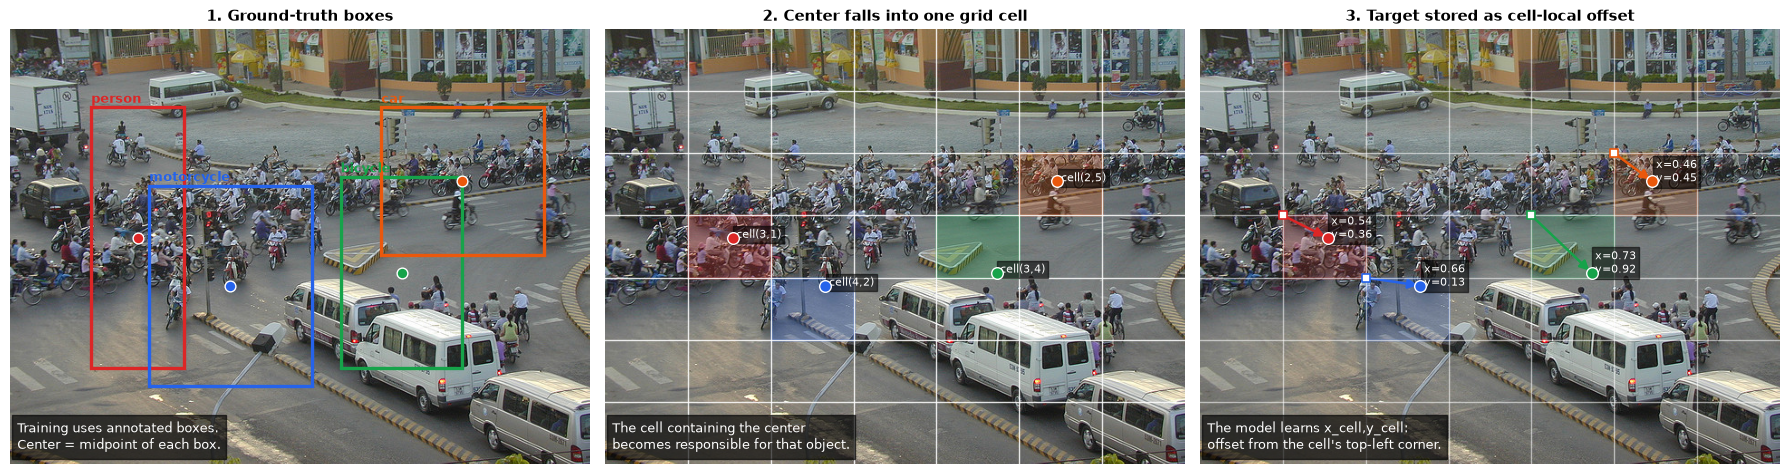

In [26]:
for obj in v1_stages['stage2_responsible_cells']:
    print(
        f"{obj['label']:10s} center={obj['center']} "
        f"-> cell(row, col)={obj['cell']} "
        f"offset_in_cell={obj['cell_offset_xy']} "
        f"encoded={obj['encoded']}"
    )
display_yolov1_responsible_cells(v1_stages)

### 3. bboxとクラスを同時に回帰する

YOLOv1の「同時に回帰する」は、**1つのセルの出力ベクトルにbbox、confidence、class確率をまとめて入れ、それらを1つの損失関数で同時に学習する**という意味です。

このデモでは、1つのセルのベクトルは次の15値です。

```text
[box1_x, box1_y, box1_w, box1_h, box1_conf,
 box2_x, box2_y, box2_w, box2_h, box2_conf,
 p_person, p_bicycle, p_motorcycle, p_car, p_bus]
```

実際のYOLOv1では、各セルは `B` 個のbbox候補を出します。ただし学習時には、その中で正解bboxと最もIoUが高いbbox predictorだけを、その物体のbbox担当にします。class確率はbboxごとではなくセルごとに予測します。

損失関数としては、CrossEntropyではなく、基本的に **MSE（Mean Squared Error / squared error）** を使います。ただし、すべての出力に同じMSEをかけるのではなく、担当するセル・bbox predictorだけをmaskし、座標誤差とno-object誤差には重みを付けます。

まず、各項を関数名ベースで書くと次のようになります。

$$
L_{xy} = MSE\left((x, y), (\hat{x}, \hat{y})\right)
$$

$$
L_{wh} = MSE\left((\sqrt{w}, \sqrt{h}), (\sqrt{\hat{w}}, \sqrt{\hat{h}})\right)
$$

$$
L_{obj} = MSE\left(C, \hat{C}\right)
$$

$$
L_{noobj} = MSE\left(0, \hat{C}\right)
$$

$$
L_{class} = MSE\left(p(class), \hat{p}(class)\right)
$$

全体としては、これらをmaskと重み付きで足し合わせます。

$$
L
= \lambda_{coord}(L_{xy} + L_{wh})
+ L_{obj}
+ \lambda_{noobj}L_{noobj}
+ L_{class}
$$

ここで、各項の意味は次の通りです。

| 項 | 何を比べるか | 損失の種類 | どこに適用するか |
|---|---|---|---|
| $L_{xy}$ | bbox中心 `x, y` | MSE | 物体を担当するbbox predictorだけ |
| $L_{wh}$ | bboxサイズ `sqrt(w), sqrt(h)` | MSE | 物体を担当するbbox predictorだけ |
| $L_{obj}$ | object confidence | MSE | 物体を担当するbbox predictorだけ |
| $L_{noobj}$ | no-object confidence | MSE | 物体を担当しないbbox predictor |
| $L_{class}$ | class確率 | MSE | 物体中心を含む担当セルだけ |

ここでいう「mask」とは、**その損失を計算する場所だけ1、それ以外を0にするスイッチ**です。YOLOv1の論文では、このスイッチを indicator function として書きます。たとえば、`obj mask` は「そのbbox predictorが物体を担当するなら有効、そうでなければ無効」という意味です。

重みは主に次の2つです。

- `lambda_coord = 5`: bbox座標の誤差を強める。位置合わせを重視するためです。
- `lambda_noobj = 0.5`: 物体がない場所のconfidence誤差を弱める。画像内の大半のセルは物体なしなので、その損失が支配的になりすぎるのを防ぎます。

bboxサイズだけ `w, h` をそのままMSEにせず、`sqrt(w), sqrt(h)` にしてからMSEを取ります。これは、大きい箱の少しのずれより、小さい箱の少しのずれを相対的に重く見るためです。

上の表で使っている値の意味は次の通りです。

- `x, y`: 担当セル内でのbbox中心座標。セル左上を基準にした0〜1の相対座標です。
- `w, h`: 画像全体に対するbbox幅・高さです。
- `confidence`: そのbbox predictorが物体を含む確からしさです。学習時には、担当bbox predictorではIoUに近い値を目標にし、物体がない場所では0へ近づけます。
- `p(class)`: class確率です。担当セルだけがclass lossを持ちます。

つまり、特別な後処理でbboxとclassを別々に作っているのではありません。**同じ出力テンソルの中にbbox回帰値とclass確率が同居しており、損失関数の各項がそれぞれの場所を同時に更新する**、というアルゴリズムです。


{
  "target_tensor_shape": [
    7,
    7,
    15
  ],
  "active_cells": [
    {
      "cell": [
        2,
        5
      ],
      "label": "car",
      "vector": {
        "x_in_cell": 0.45999999999999996,
        "y_in_cell": 0.44999999999999973,
        "w_image": 0.28,
        "h_image": 0.34,
        "confidence": 1.0,
        "class_probs": {
          "person": 0.0,
          "bicycle": 0.0,
          "motorcycle": 0.0,
          "car": 1.0,
          "bus": 0.0
        }
      },
      "decoded_xyxy": [
        0.64,
        0.17999999999999997,
        0.92,
        0.52
      ]
    },
    {
      "cell": [
        3,
        1
      ],
      "label": "person",
      "vector": {
        "x_in_cell": 0.54,
        "y_in_cell": 0.3599999999999999,
        "w_image": 0.15999999999999998,
        "h_image": 0.6000000000000001,
        "confidence": 1.0,
        "class_probs": {
          "person": 1.0,
          "bicycle": 0.0,
          "motorcycle": 0.0,
          "car": 0.0,


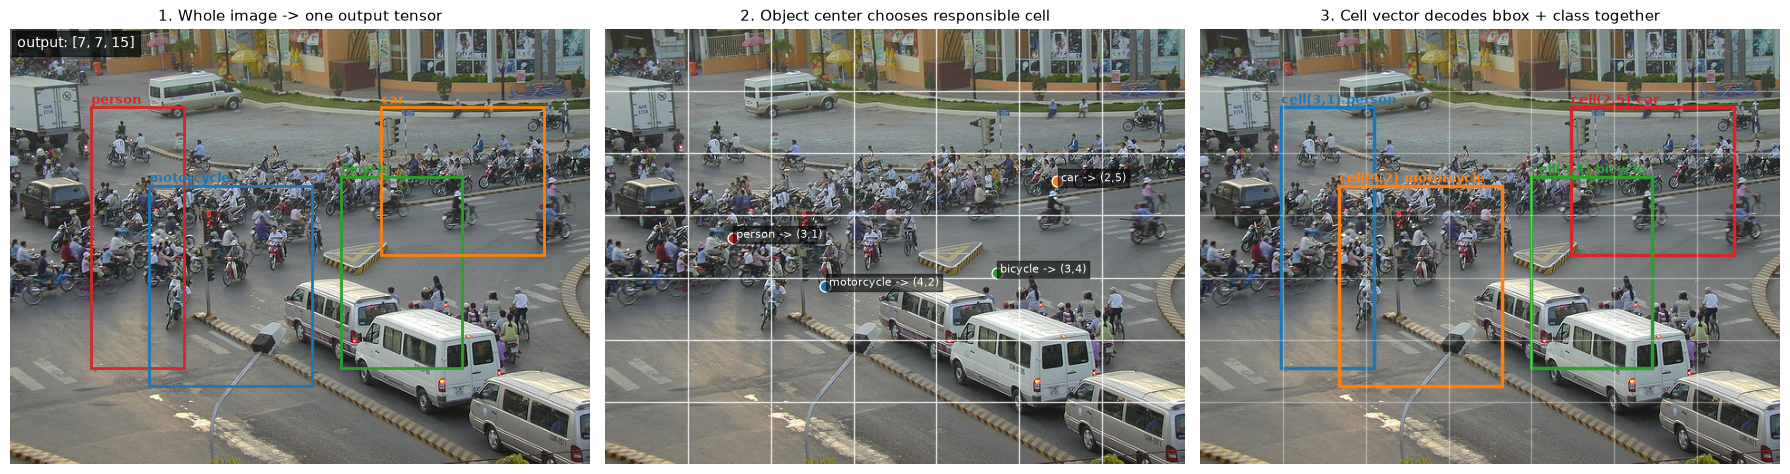

In [27]:
print(json.dumps(v1_stages['stage3_joint_regression'], ensure_ascii=False, indent=2))
loss_demo = compute_yolov1_loss_demo(v1_stages)
print(json.dumps({
    'loss_weights': {
        'lambda_coord': loss_demo['lambda_coord'],
        'lambda_noobj': loss_demo['lambda_noobj'],
    },
    'first_object_loss_example': loss_demo['rows'][0]['weighted_loss'],
    'noobject_confidence_example': loss_demo['noobject_example'],
    'total_loss_breakdown': loss_demo['totals'],
}, ensure_ascii=False, indent=2))
display_yolov1_stages(v1_stages)

## YOLOv2 / YOLO9000 (2017)

### アーキテクチャ全体像

YOLOv2は、YOLOv1の全結合層中心の最終出力から、より畳み込み的な検出器へ寄せた世代です。backboneにはDarknet-19を使い、分類タスクで事前学習したあと、入力解像度を上げて分類器を再調整し、最後に検出用へfine-tuningします。検出headは各グリッドセルごとに複数のanchorを持ち、各anchorについて位置offset、objectness、classを予測します。つまり、v1の「セルごとにbbox候補を直接出す」構造から、「セルとanchorの組み合わせごとに、事前に置いた箱からのずれを出す」構造へ変わりました。

passthrough層は、特徴抽出器がすべて終わった後に新しく画像を処理する層ではありません。YOLOv2では基本的に **1箇所だけ**、Darknet-19の途中にある高解像度特徴を取り出し、reorgで13 x 13に合わせてから、検出head直前の深い特徴へchannel方向に結合します。

**新しく加わった技術:** anchor box、k-meansによるbox事前分布、Batch Normalizationと高解像度分類事前学習、passthrough層、階層分類によるYOLO9000。

出典: [公式/著者実装](https://github.com/pjreddie/darknet) / [論文](https://arxiv.org/abs/1612.08242)

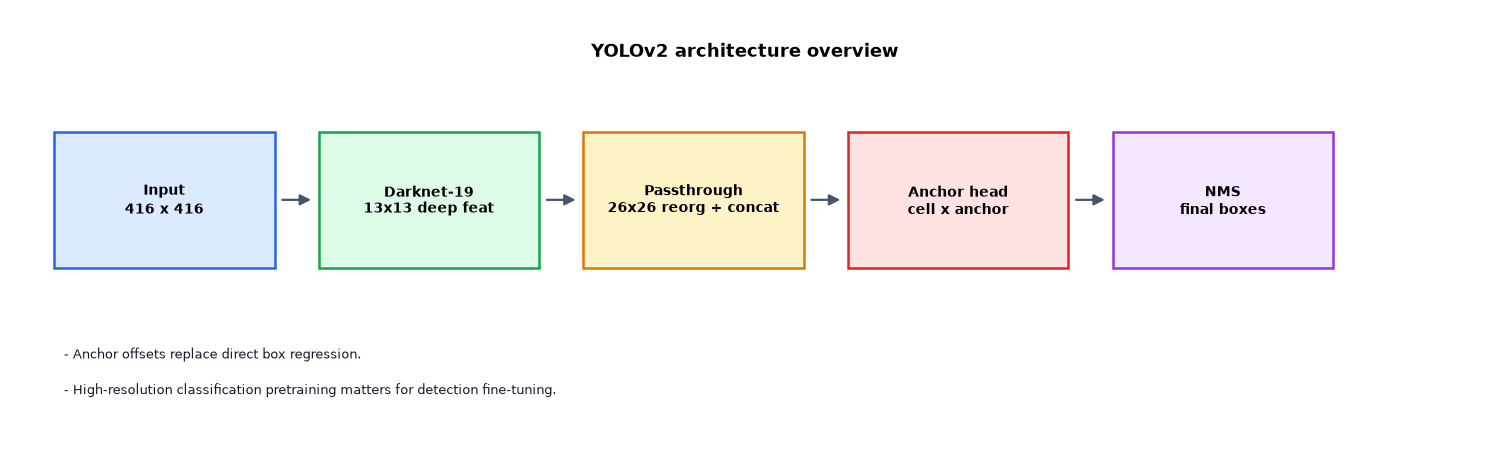

In [57]:
display_yolo_architecture(2)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. anchor box

YOLOv1ではセルがbboxの幅高さまで直接回帰していました。YOLOv2では、各セルに複数の基準箱(anchor)を置き、モデルはその基準箱からのずれを予測します。これにより、縦長・横長・大きい・小さいといった形状を、学習開始時点から候補として持てます。検出headの出力単位も「セル」だけでなく「セルとanchorの組み合わせ」になります。

bboxの中心座標は、担当セルの中に収めたい値です。そのためネットワークの生出力 $t_x,t_y$ をそのまま座標にせず、sigmoid関数で0から1の範囲へ押し込みます。ここで $\sigma$ はsigmoid関数です。

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

$$
b_x = \sigma(t_x) + c_x, \quad b_y = \sigma(t_y) + c_y
$$

$(c_x,c_y)$ はgrid上のセル位置なので、$\sigma(t_x),\sigma(t_y)$ は「そのセルの左上から見たセル内offset」になります。つまり中心点は、セル位置 + セル内offset として決まります。

一方、bboxの幅高さは正の値でなければいけません。そこで $t_w,t_h$ には指数関数をかけ、必ず正になる倍率として使います。anchorの幅高さ $(p_w,p_h)$ にその倍率を掛けることで、「基準箱をどれだけ拡大・縮小するか」を予測します。

$$
b_w = p_w e^{t_w}, \quad b_h = p_h e^{t_h}
$$

ここで $(p_w, p_h)$ はanchorの幅高さ、$(t_x,t_y,t_w,t_h)$ はネットワーク出力です。この決め方により、中心は担当セルの近くに安定して置かれ、幅高さはanchorを基準にした正のスケールとして表現されます。

#### 2. k-meansによるbox事前分布

ここでいう「bboxの幅高さをクラスタリングする」とは、学習データに含まれる正解bboxから **位置情報を捨てて、形だけを見る** という意味です。

たとえば、学習データ中に次のような正解bboxがあるとします。ここでは画像全体の幅高さを1として正規化しています。

| object | center x | center y | width | height |
|---|---:|---:|---:|---:|
| person | 0.42 | 0.55 | 0.12 | 0.45 |
| bottle | 0.70 | 0.48 | 0.08 | 0.30 |
| car | 0.50 | 0.62 | 0.55 | 0.22 |
| bus | 0.46 | 0.50 | 0.70 | 0.32 |

anchorを決めるときには、`center x` と `center y` は使いません。使うのは `width` と `height` だけです。

$$
box_i = (w_i, h_i)
$$

つまり、personやbottleのような「細長い箱」、carやbusのような「横長の箱」を、形が似ているもの同士でグループに分けます。このグループ分けがk-meansです。たとえば $k=2$ なら、代表的な箱の形を2種類作ります。

$$
\{(w_i,h_i)\}_{i=1}^{N} \rightarrow \{(p_{w,1},p_{h,1}), (p_{w,2},p_{h,2}), \ldots, (p_{w,k},p_{h,k})\}
$$

このクラスタ中心 $(p_w,p_h)$ が、YOLOv2で使うanchorの幅高さになります。つまりanchorは「学習データによく出るbbox形状の代表値」です。

通常のk-meansでは距離としてユークリッド距離を使いますが、bboxでは大きい箱ほど距離が大きくなりやすく、検出にとっての近さとずれることがあります。そこでYOLOv2では、幅高さだけを持つ2つの箱を同じ中心に置いたと仮定し、IoUで似ているかを測ります。

$$
d(box, centroid) = 1 - IoU(box, centroid)
$$

IoUが高いほど形が似ているので距離は小さくなります。こうして作ったanchorを使うことで、モデルはbboxの形をゼロから毎回学ぶのではなく、「よくある形からのずれ」を学べるようになります。

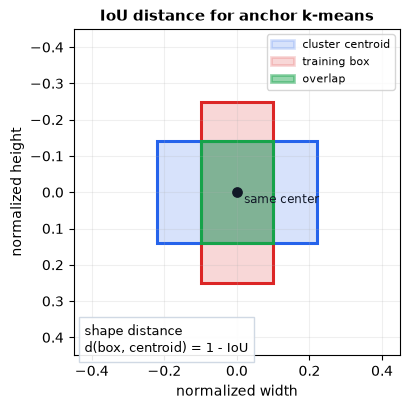

In [58]:
display_yolo_element_demo(2, 'kmeans')

#### 3. Batch Normalizationと高解像度分類事前学習

この2つは直接つながった1つの処理ではなく、YOLOv2で導入された **別々の学習改善** です。

1つ目のBatch Normalizationは、ネットワーク内部の各層を学習しやすくするための工夫です。畳み込み層の出力をmini-batch内の平均と分散で正規化し、その後に学習可能なスケール $\gamma$ とシフト $\beta$ をかけます。これにより勾配が不安定になりにくく、学習が速く安定します。またmini-batch統計によるノイズが入るため、結果的に正則化効果もあります。

$$
\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\epsilon}}, \quad y=\gamma\hat{x}+\beta
$$

2つ目の高解像度分類事前学習は、検出用fine-tuningへ移る前の準備です。YOLOv2では、まずImageNet分類でbackboneを事前学習します。ただし分類でよく使う入力解像度と、検出で使う高解像度入力には差があります。そこで、いきなり検出へ移るのではなく、分類タスクのまま入力解像度を上げて追加学習します。

流れとしては次のようになります。

$$
224px\ classification\ pretraining \to 448px\ classification\ fine\ tuning \to detection\ fine\ tuning
$$

つまり、BNは **ネットワーク内部の学習を安定させる層の工夫** で、高解像度分類事前学習は **分類モデルを検出用の入力解像度に慣らす学習スケジュールの工夫** です。両者はどちらもYOLOv2の精度改善に効きますが、役割は別です。

#### 4. passthrough層

passthrough層は、YOLOv2が小さい物体を見つけやすくするために入れた特徴結合の仕組みです。ポイントは、**深い層の特徴だけでは位置の細かさが足りないので、浅い層の細かい特徴も検出headへ渡す** ことです。

これは残差結合(residual connection)とは違います。残差結合は通常、入力 $x$ と変換後の特徴 $F(x)$ を **足し算** します。

$$
y = x + F(x)
$$

一方、YOLOv2のpassthrough層は、浅い特徴をreorgして、深い特徴と **channel方向に結合(concat)** します。

$$
F_{detect} = concat(F_{deep}, reorg(F_{shallow}))
$$

つまり、考え方としては「前の層の特徴を後ろへ渡すskip connection系の処理」に近いですが、残差結合のように同じshapeの特徴を足す処理ではありません。YOLOv2のpassthroughは、異なる解像度の特徴を検出headで一緒に使うためのreorg + concatです。

CNNでは層が深くなるほど、通常は空間解像度が下がります。たとえば入力画像から特徴抽出を進めると、途中には比較的細かい `26 x 26` の特徴マップがあり、最後の検出直前にはより粗い `13 x 13` の特徴マップがあります。

```text
浅い特徴: 26 x 26 x C    位置情報が細かいが、意味情報は弱め
深い特徴: 13 x 13 x D    意味情報が強いが、位置情報は粗い
```

YOLOv2の最終検出は `13 x 13` のgrid上で行います。そのため、`26 x 26` の浅い特徴をそのまま `13 x 13` の深い特徴に結合することはできません。高さと幅が合わないからです。

そこでpassthrough層では、`26 x 26` の特徴を **2 x 2 の近傍ごとにまとめて、channel方向へ並べ替えます**。これは畳み込みではなく、reshapeに近い並べ替え操作です。

$$
26 \times 26 \times C \rightarrow 13 \times 13 \times 4C
$$

なぜchannel数が4倍になるかというと、`26 x 26` 上の `2 x 2` の4マスを、`13 x 13` 上の1マスに対応させるからです。

```text
26 x 26上の2 x 2領域:
[a b]
[c d]

13 x 13上の1セルのchannel方向へ移す:
[..., a, b, c, d, ...]
```

この変換により、空間サイズは `26 -> 13` と半分になりますが、失った4マス分の情報はchannel方向に保存されます。その後、変換済みの浅い特徴 `13 x 13 x 4C` を、深い特徴 `13 x 13 x D` と結合します。

したがって、head直前で検出に使う特徴のchannel数は、深い特徴だけの場合より増えます。単純化して書くと、concat後のchannel数は `D + 4C` です。ただし、これは「ネットワーク全体のchannel数がどこまでも巨大になる」という意味ではありません。増えるのはpassthroughで結合する地点であり、その後の畳み込み層や検出headで必要な出力channelへ変換されます。

$$
F_{detect} = concat(F_{deep}^{13\times13\times D}, reorg(F_{shallow}^{26\times26\times C}))
$$

挿入位置としては、画像入力の直後でも、特徴抽出器の完全な後でもありません。YOLOv2ではpassthroughは基本的に1箇所で、Darknet-19の途中特徴を分岐して取り出し、最終検出headの直前で深い特徴に結合します。

```text
入力画像
  -> Darknet-19の途中特徴 26 x 26 x C -- reorg --+
  -> Darknet-19の深い特徴 13 x 13 x D ---------- concat -> 検出head
```

つまりpassthrough層は、最終検出headに対して、深い意味情報だけでなく、浅い層に残っている細かい位置情報も渡すための仕組みです。YOLOv3以降のmulti-scale predictionやFPN的な特徴融合ほど本格的ではありませんが、「異なる解像度の特徴を検出に使う」という流れの前段階です。

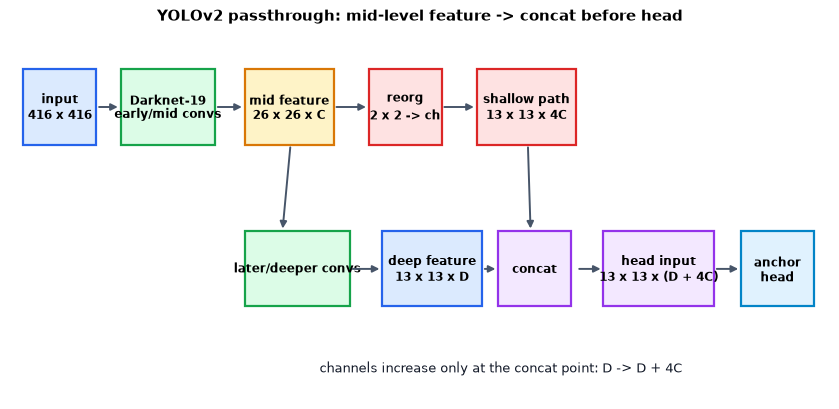

In [59]:
display_yolo_element_demo(2, 'passthrough')

#### 5. 階層分類によるYOLO9000

YOLO9000の目的は、bbox付きの検出データだけではカテゴリ数が少ないため、ImageNetのような大量の分類データも使って、検出できるカテゴリ数を増やすことです。

問題は、検出データと分類データで持っている教師情報が違うことです。

```text
検出データ:
画像 + bbox + bboxごとのclass
例: この領域は dog

分類データ:
画像 + 画像全体のclass
例: この画像は Norfolk terrier
```

分類データにはbboxがありません。そのため、分類データだけからは「どこに物体があるか」は直接学べません。一方で、「その画像にどんな種類の物体が写っているか」は学べます。YOLO9000は、この分類ラベルを検出器のclass prediction側の学習に使いたい、という発想です。

そのために、COCOの検出クラスとImageNetの分類クラスを、WordTreeのような階層構造でつなぎます。たとえば次のような木を考えます。

```text
entity
└── animal
    └── dog
        └── terrier
            └── Norfolk terrier
```

通常のflatな分類では、`dog`, `cat`, `car`, `Norfolk terrier` などを全部同じ階層のclassとして扱います。しかしYOLO9000では、`Norfolk terrier` は `terrier` の一種であり、`terrier` は `dog` の一種であり、`dog` は `animal` の一種である、という関係を使います。

確率も、全classに対する1つのsoftmaxではなく、木の各分岐で条件付き確率として扱います。

$$
P(Norfolk\ terrier) = P(Norfolk\ terrier \mid terrier) P(terrier \mid dog) P(dog \mid animal) P(animal \mid entity)
$$

つまり、葉classの確率は、rootからそのclassまでの経路上の条件付き確率を掛け合わせて計算します。

この条件付き確率は、各親ノードごとに、その子ノード集合だけを候補にしたsoftmax分類として学習します。たとえば正解ラベルが `dog` で、経路が `entity -> animal -> dog` なら、学習する分岐は次の2つです。

```text
children(entity) の中から animal を選ぶ
children(animal) の中から dog を選ぶ
```

lossとしては、経路上の各分岐でcross entropyを計算して足します。

$$
L = CE(animal, children(entity)) + CE(dog, children(animal))
$$

正解ラベルが `Norfolk terrier` のように細かい場合は、経路が長くなります。

```text
entity -> animal -> dog -> terrier -> Norfolk terrier
```

この場合は、各階層の分岐に対してcross entropyを足します。

$$
L = CE(animal, children(entity)) + CE(dog, children(animal)) + CE(terrier, children(dog)) + CE(Norfolk\ terrier, children(terrier))
$$

この形にすると、検出データで `dog` までしかラベルがなくても、`entity -> animal -> dog` までの経路を学習できます。一方、分類データで `Norfolk terrier` という細かいラベルがあれば、`dog -> terrier -> Norfolk terrier` のような細かい分類知識を学習できます。

```text
COCO検出データ:
  bbox位置 + objectness + dogまでの分類経路を学ぶ

ImageNet分類データ:
  bbox位置は学べない
  ただし Norfolk terrier までの細かい分類経路を学ぶ
```

重要なのは、分類データがbbox回帰を直接改善するわけではないことです。分類データは主に、検出器が出すclass predictionを細かいカテゴリまで拡張するために使われます。bboxの位置やobjectnessは、bbox付きの検出データから学びます。

また、この階層分類は「Darknet-19の分類事前学習だけで使う仕組み」ではありません。ImageNet分類事前学習とは別に、YOLO9000で検出データと分類データを混ぜて共同学習するときに使います。

```text
分類事前学習:
  backboneを分類に強くするための準備

YOLO9000の共同学習:
  検出データで位置を学び、分類データで細かいclass経路を学ぶ
```

つまりWordTreeは、検出器を学習している途中で分類画像も利用し、class prediction側を多数カテゴリへ拡張するための仕組みです。この仕組みにより、YOLO9000は「位置を学ぶための検出データ」と「カテゴリを増やすための分類データ」を同じモデル内で共同利用しようとしました。名前のYOLO9000は、9000種類以上のカテゴリを扱うことを狙った点に由来します。

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

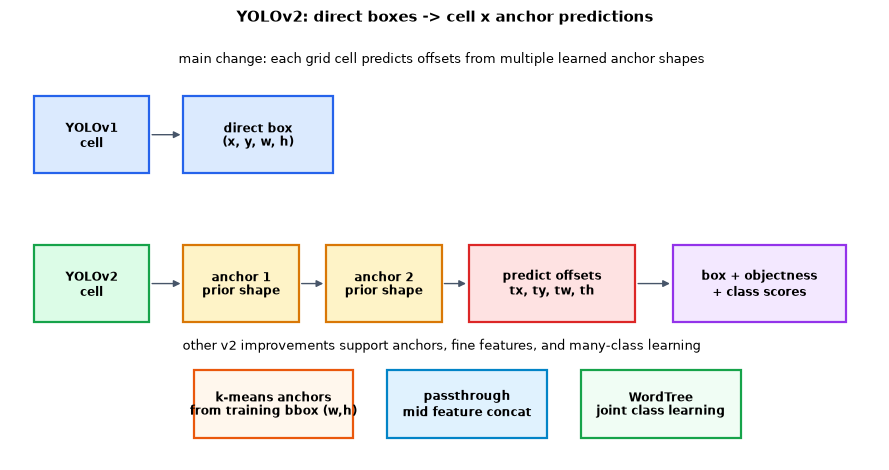

In [60]:
display_yolo_technology_demo(2)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(2, ['--mode', 'infer', '--image', 'images/sample.jpg', '--config', 'path/to/yolov2.cfg', '--weights', 'path/to/yolov2.weights'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOv3 (2018)

### アーキテクチャ全体像

YOLOv3は、YOLOv2のanchor-based検出を引き継ぎつつ、backboneをDarknet-53へ深くし、検出headを3つの解像度へ増やした世代です。入力を416 x 416とすると、stride 32の13 x 13、stride 16の26 x 26、stride 8の52 x 52の3つの特徴マップでbboxを予測します。

YOLOv2では主に13 x 13の検出gridで予測していました。これは大きい物体には向きますが、小さい物体では1つの物体がごく少数のcellにしか対応せず、位置情報が粗くなります。YOLOv3では、深い特徴から大物体を予測し、upsampleした特徴を浅い特徴と結合して中・小物体を予測します。

```text
入力 416 x 416
  -> Darknet-53 backbone
  -> 13 x 13 head   stride 32   大きい物体向け
  -> 26 x 26 head   stride 16   中くらいの物体向け
  -> 52 x 52 head   stride 8    小さい物体向け
```

各scaleでは、各cellごとに複数のanchorを持ちます。COCO設定なら各scaleに3 anchorを置き、各anchorについてbbox、objectness、class scoreを予測します。つまりYOLOv3の主な変化は、YOLOv2の「cell x anchor」予測を、複数の特徴解像度へ展開したことです。

**新しく加わった技術:** 3スケール予測、FPN的な特徴融合、独立ロジスティック分類。

出典: [公式/著者実装](https://github.com/pjreddie/darknet) / [論文](https://arxiv.org/abs/1804.02767)

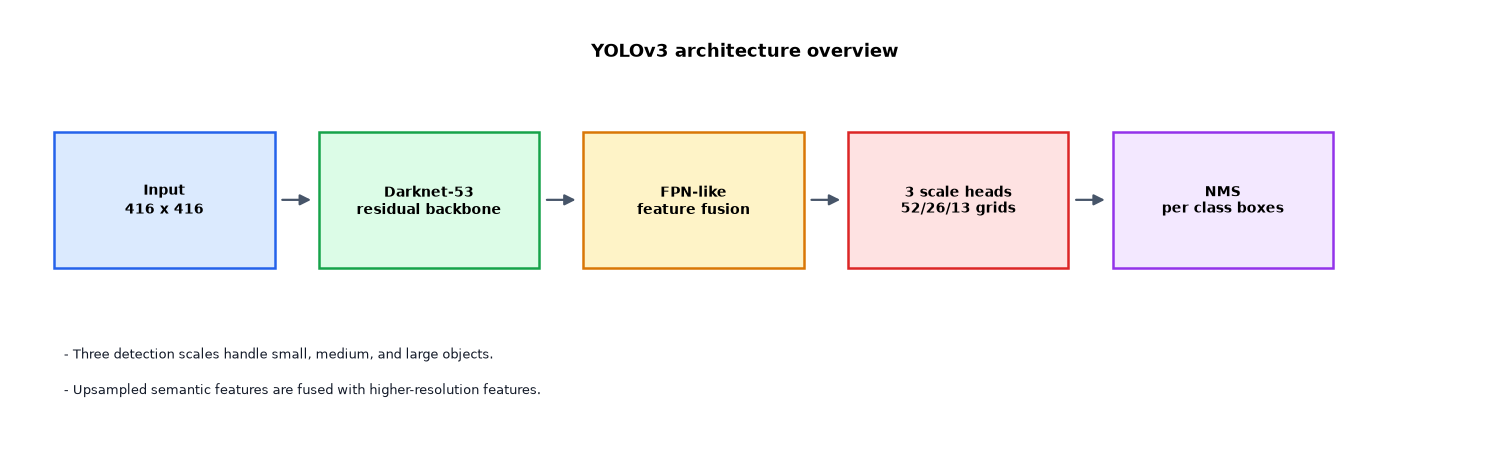

In [3]:
display_yolo_architecture(3)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. 3スケール予測

YOLOv3では、1つのgridだけでなく、3つの解像度で検出します。入力サイズが416 x 416の場合、各headのgrid sizeはstrideで決まります。

$$
\text{grid size} = \frac{\text{input size}}{\text{stride}}
$$

具体的には次のようになります。

| head | stride | grid | 主に担当しやすい物体 |
|---|---:|---:|---|
| head 1 | 32 | 13 x 13 | 大きい物体 |
| head 2 | 16 | 26 x 26 | 中くらいの物体 |
| head 3 | 8 | 52 x 52 | 小さい物体 |

なぜ小さい物体には52 x 52が効くのでしょうか。13 x 13では1 cellがおおよそ32 x 32 pixelに対応します。一方、52 x 52では1 cellがおおよそ8 x 8 pixelに対応します。小さい物体は粗いgridでは位置が潰れやすいので、細かいgridで予測した方が中心位置やbboxを表しやすくなります。

各scaleでは、cellごとに3つのanchorを使います。COCOの80 class設定なら、1 anchorあたりの出力は次です。

$$
4\ bbox + 1\ objectness + 80\ class = 85
$$

ここで `class` は「そのbbox内の物体がどのカテゴリか」を表すカテゴリ別スコアです。COCOには `person`, `car`, `dog` など80カテゴリがあるため、1 anchorごとに80個のclass scoreを出します。つまり1つのbbox候補は、位置と大きさだけでなく、objectnessと全カテゴリ分のスコアをまとめて持ちます。推論時には、多くの場合 `objectness * class score` をカテゴリごとの最終スコアとして使います。

そのためYOLOv3のhead出力はかなり情報量が多くなります。たとえば13 x 13 headだけでも、`13 x 13 x 3 = 507` 個のbbox候補があり、それぞれが85個の値を持ちます。3つのscaleを合わせると、候補数は `13 x 13 x 3 + 26 x 26 x 3 + 52 x 52 x 3 = 10647` 個になります。ここからconfidence thresholdやNMSで重複・低信頼の候補を削り、最終的な検出結果だけを残します。

したがって、各scaleの出力shapeは概念的には次のようになります。

$$
13 \times 13 \times 3 \times 85,
\quad
26 \times 26 \times 3 \times 85,
\quad
52 \times 52 \times 3 \times 85
$$

YOLOv2からの変化は、anchorを使うこと自体ではなく、anchor-based predictionを複数解像度の特徴マップで行うようになった点です。

#### 2. FPN的な特徴融合

YOLOv3の3スケール予測では、単に3つのheadを独立に置くだけではありません。深い層の意味情報をupsampleし、浅い層の高解像度特徴とconcatしてから、中・小物体用のheadへ渡します。

深い特徴は、物体カテゴリや全体形状のような意味情報に強いです。一方、浅い特徴は、輪郭や位置の細かさを保っています。YOLOv3ではこの2つを結合します。

$$
F_{26} = concat(F_{mid}, upsample(F_{13}))
$$

さらに同じ考え方で、26 x 26側の特徴をupsampleして、52 x 52側の浅い特徴と結合します。

$$
F_{52} = concat(F_{shallow}, upsample(F_{26}))
$$

この流れにより、52 x 52の小物体headでも、浅い位置情報だけでなく、深い層から来た意味情報を使えます。これはYOLOv2のpassthroughより体系的な特徴融合です。ただし、YOLOv4以降のPANやSPPまで含むneckとは区別して、YOLOv3ではFPN的なtop-down fusionとして理解するとよいです。

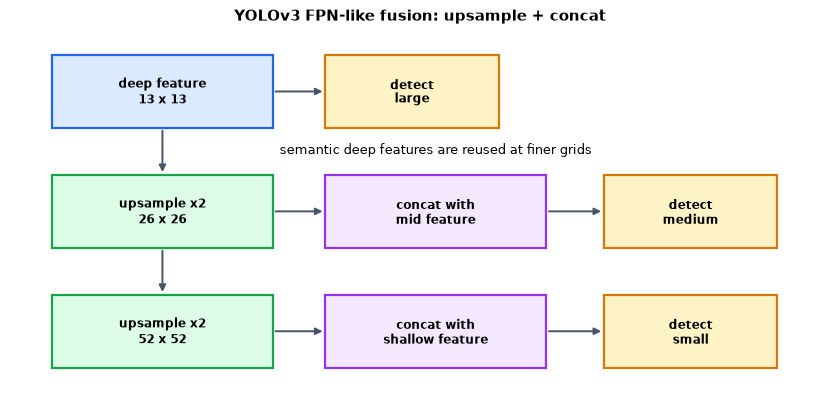

In [3]:
display_yolo_element_demo(3, 'yolov3_fusion')

#### 3. 独立ロジスティック分類

YOLOv3では、class predictionにsoftmaxではなく、classごとの独立したlogistic classifierを使います。つまり、各classについてsigmoidで確率を出します。

$$
P(class_k)=\sigma(z_k)=\frac{1}{1+e^{-z_k}}
$$

softmaxでは、全classの確率和が1になるため、基本的に「どれか1つのclass」を選ぶ形になります。

$$
P(class_k)=\frac{e^{z_k}}{\sum_j e^{z_j}}
$$

一方、独立logisticではclassごとにbinary classificationとして扱います。

$$
L_{class}=\sum_k BCE(y_k, \hat{y}_k)
$$

これにより、class同士が完全に排他的であるという仮定を弱められます。YOLOv3論文では、Open Imagesのようにラベルが重なり得るデータセットを意識して、この設計を採用しています。

注意点として、これはbboxを複数classに無制限に割り当てるための後処理というより、学習時のclass lossをsoftmax CEからclassごとのBCEへ変えた、という理解が重要です。bbox位置やobjectnessは別の出力として学習されます。

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

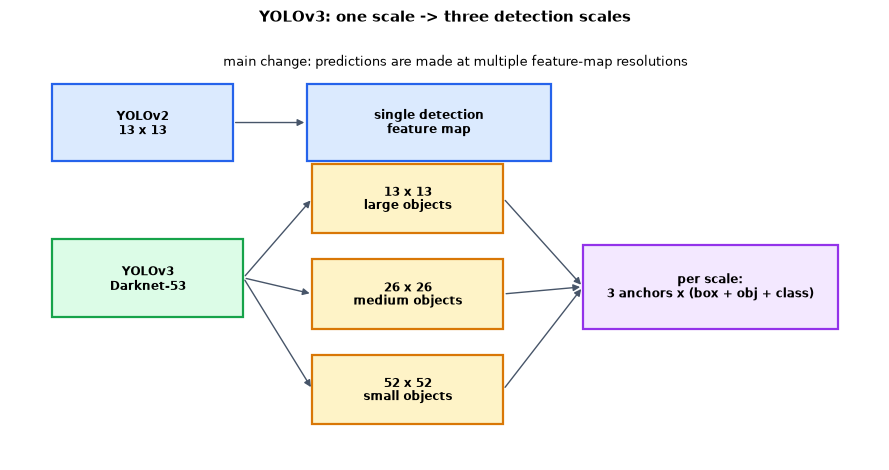

In [4]:
display_yolo_technology_demo(3)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(3, ['--mode', 'infer', '--image', 'images/sample.jpg', '--config', 'path/to/yolov3.cfg', '--weights', 'path/to/yolov3.weights'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOv4 (2020)

### アーキテクチャ全体像

YOLOv4は、単一の新アイデアだけでなく、backbone、neck、head、学習手法を体系的に組み合わせた世代です。backboneにCSPDarknet53、neckにSPPとPAN、headにYOLO系anchor headを使います。さらにMosaic augmentation、CIoU loss、DropBlock、SATなどを組み合わせ、単一GPUでも高い速度精度比を狙います。ここで重要なのは、推論時のモデル構造だけでなく、学習時に何を入れるかが検出性能を大きく左右する、という視点です。

YOLOv3までで「複数スケールでanchor-based predictionを行う」形が見えてきました。YOLOv4では、その検出head自体を大きく変えるというより、入力 augmentation、backbone の特徴抽出、neck の特徴融合、bbox loss をまとめて改善します。つまり、1つの式だけを覚える節ではなく、検出器全体の各部品がどこで効くかを見る節です。

```text
入力画像 + Mosaic等の学習工夫
  -> CSPDarknet53 backbone
  -> SPP + PAN neck
  -> anchor-based YOLO head
  -> CIoU loss / NMS
```

**新しく加わった技術:** CSPDarknet53、SPP + PAN、Mish、CIoU loss、MosaicなどのBoF/BoS。

出典: [公式/著者実装](https://github.com/AlexeyAB/darknet) / [論文](https://arxiv.org/abs/2004.10934)

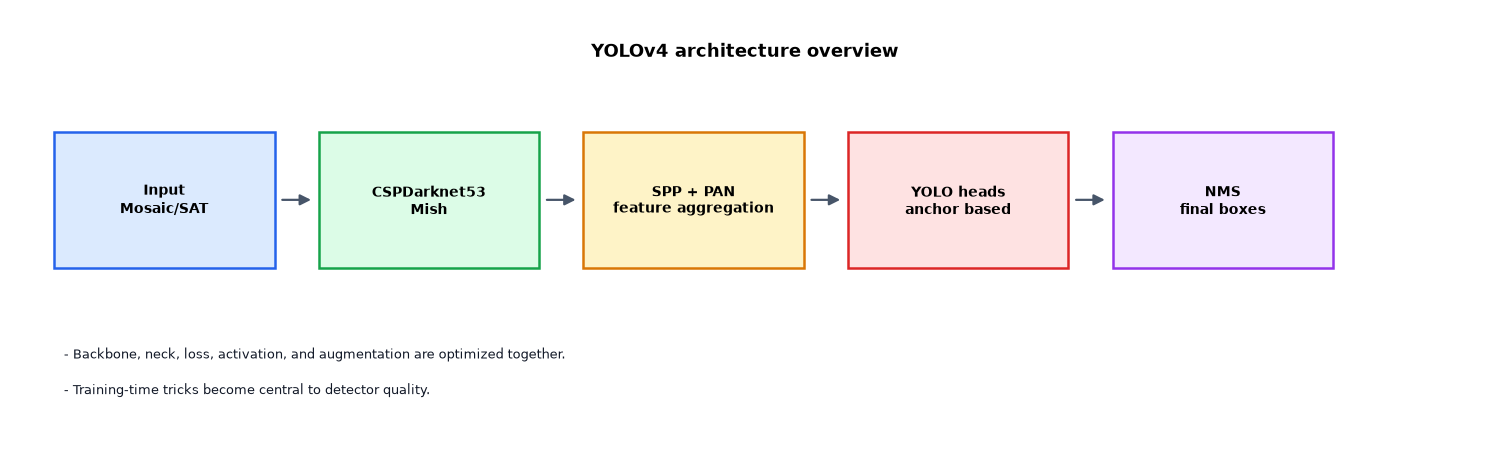

In [9]:
display_yolo_architecture(4)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. CSPDarknet53

CSPDarknet53は、YOLOv3のDarknet系backboneをそのまま深くするのではなく、CSP（Cross Stage Partial）構造を組み込んだbackboneです。backboneの役割は、入力画像を何段階かの特徴マップへ変換し、後ろのneck/headが使う材料を作ることです。

CSPでは、あるstageに入ってきた特徴 `X` をchannel方向に2つへ分けます。一方は畳み込みblock列へ通して新しい特徴を作り、もう一方は短い経路で保持します。最後に2つをchannel方向にconcatし、畳み込みで混ぜます。

$$
X = concat(X_1, X_2)
$$

$$
Y = Conv(concat(X_1, F(X_2)))
$$

ここで `F(X_2)` は複数の畳み込みや残差blockを通った重い変換です。`X_1` は完全に何もしないわけではありませんが、主に短い経路として情報を保ちます。重要なのは、すべてのchannelを毎回重いblockへ通さないことです。これにより計算量とメモリ使用量を抑えつつ、変換された特徴と保持された特徴を最後に再結合できます。

`concat` は足し算ではありません。channel方向に並べる操作なので、concat直後はchannel数が増えます。たとえば `X_1` が64 channel、`F(X_2)` が64 channelなら、concat後は128 channelになります。その後の `Conv` で特徴を混ぜ、必要なchannel数へ整理します。

YOLOv4でCSPDarknet53が効く理由は、速度と精度の両方に関係します。深いbackboneは表現力を上げますが、そのまま重くするとリアルタイム性が落ちます。CSPは、特徴の一部を短い経路で残すことで勾配も流しやすくし、重い変換の計算を全channelにかけないことで、backboneを実用的な重さに保ちます。


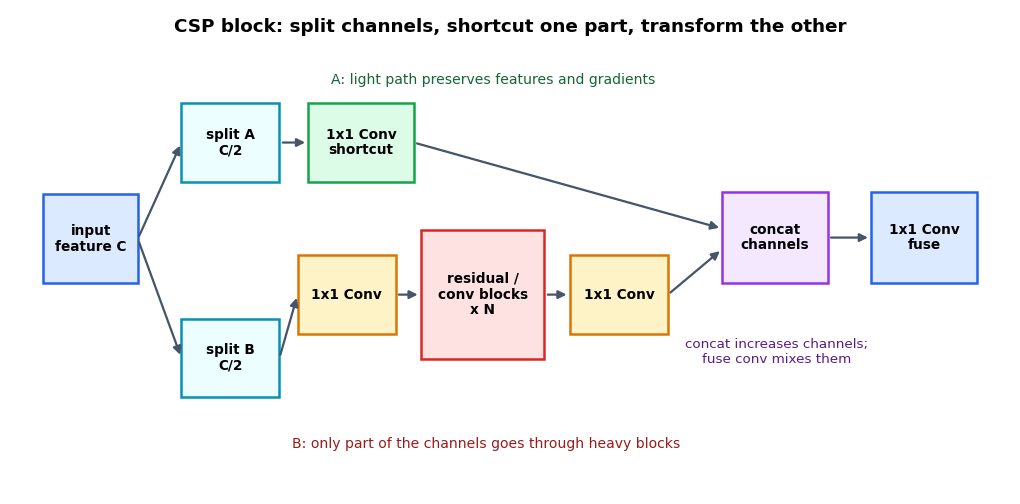

In [12]:
display_yolo_element_demo(4, 'csp')

#### 2. SPP + PAN

YOLOv4では、backboneが作った特徴をそのままheadへ渡すのではなく、neckで検出しやすい形へ混ぜます。このneckに入る代表的な部品がSPPとPANです。YOLOv3でも複数scaleの特徴を使いましたが、YOLOv4では「広い文脈を見るSPP」と「上下方向に特徴を流すPAN」を組み合わせ、各scaleの検出headへ渡す特徴を強くします。

SPP（Spatial Pyramid Pooling）は、同じ特徴マップ `F` に対して異なるpoolingサイズをかけます。たとえば小さいpoolingは近くの局所情報を見て、大きいpoolingは広い範囲の文脈を見ます。それらをchannel方向にconcatすると、同じ空間位置に対して複数の受容野を持つ特徴をまとめられます。

$$
F_{SPP}=concat(pool_{1}(F), pool_{5}(F), pool_{9}(F), pool_{13}(F))
$$

ここでもconcatなので、直後はchannel数が増えます。その後の畳み込みでchannelを整理し、後段のPANへ渡します。SPPの狙いは、bboxを出す直前の特徴に広い文脈を入れることです。たとえば物体の一部だけを見るより、周辺まで見た方がカテゴリや大きさを判断しやすい場合があります。

PAN（Path Aggregation Network）は、複数解像度の特徴を双方向に流します。YOLOv3のFPN的な流れでは、深い低解像度特徴をupsampleして、浅い高解像度特徴と結合しました。これは小物体headに意味情報を戻すためです。PANではさらに逆方向、つまり高解像度側の位置情報をdownsampleして低解像度側へ戻す経路も加えます。

```text
深い特徴  -> upsample   -> 浅い特徴とconcat   # top-down
浅い特徴  -> downsample -> 深い特徴とconcat   # bottom-up
```

この結果、小物体向けのheadは細かい位置情報と深い意味情報を持ち、大物体向けのheadも浅い層由来の位置情報を受け取れます。YOLOv4のSPP + PANは、headそのものを完全に新しくするというより、headへ渡すmulti-scale特徴の質を上げるためのneckです。


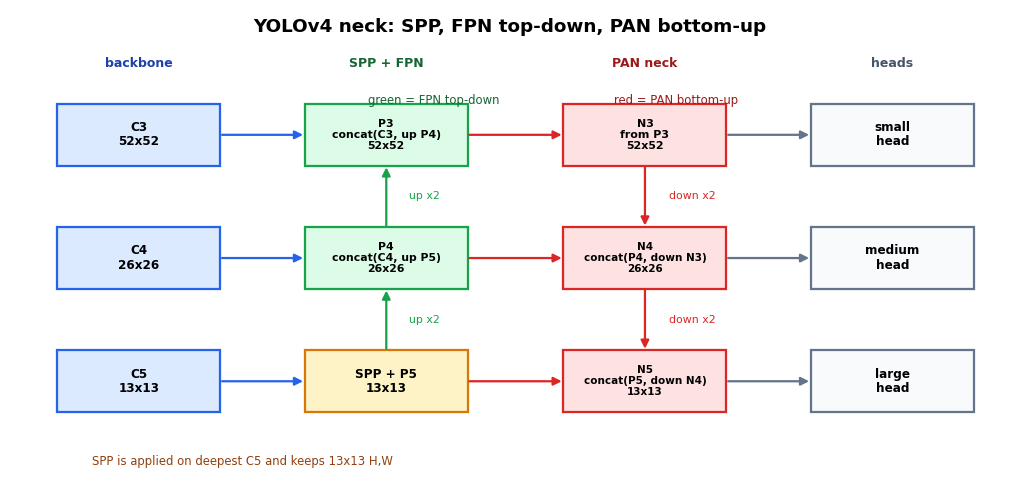

In [13]:
display_yolo_element_demo(4, 'spp_pan')

#### 3. Mish

MishはYOLOv4で使われた活性化関数です。活性化関数は、畳み込みの出力に非線形性を入れる部品です。bboxを直接出すheadの仕組みではなく、主にbackbone内部で特徴を変換するときに使われます。

$$
Mish(x)=x\tanh(\ln(1+e^x))
$$

ReLUは次のように、入力が負のとき出力を0にします。

$$
ReLU(x)=\max(0,x)
$$

ReLUは単純で速い一方、負側の情報と勾配が完全に切れます。Leaky ReLUは負側に小さな傾きを残します。Mishはさらに滑らかな曲線で、負側も完全には切らず、正側へなめらかにつながります。

```text
畳み込み出力 x
  -> BatchNormなど
  -> Mish(x)
  -> 次の畳み込み層
```

YOLOv4でMishを見るときのポイントは、「検出の出力形式を変える技術ではない」ということです。anchorの数、bboxの表現、class scoreの数がMishで変わるわけではありません。Mishは、backboneが作る特徴の表現力や学習の滑らかさに効く部品です。

ただし、活性化関数だけでYOLOv4の性能が決まるわけではありません。YOLOv4はCSPDarknet53、SPP/PAN、CIoU、Mosaicなどをまとめて組み合わせた設計です。Mishはその中で、backbone側の特徴抽出を支える要素として位置づけると理解しやすいです。


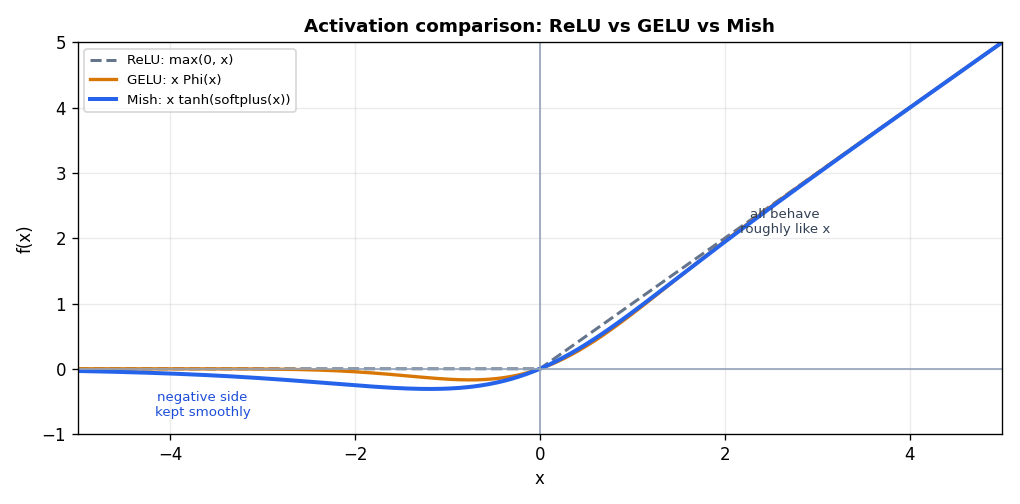

In [14]:
display_yolo_element_demo(4, 'mish')

#### 4. CIoU loss

CIoU lossは、bbox回帰を学習するときのlossです。YOLOv1では座標にMSEを使う説明をしましたが、YOLOv4では「予測boxと正解boxがどれくらい良い対応になっているか」を、よりbboxらしい尺度で評価します。

まずIoUは、予測boxと正解boxの重なりを見ます。

$$
IoU = \frac{|B \cap B^{gt}|}{|B \cup B^{gt}|}
$$

IoUが高いほどbox同士はよく重なっています。しかし、IoUだけでは足りない場合があります。たとえば学習初期にbox同士がまったく重ならないと、IoUは0になり、どちらへ動かせばよいかの情報が弱くなります。また、同じIoUでも中心が近いboxと遠いbox、縦横比が近いboxと崩れたboxでは、bboxとしての品質が違います。

CIoUは、次の3つを同時に見ます。

| 項 | 見ているもの | 役割 |
|---|---|---|
| `1 - IoU` | boxの重なり | 正解とどれだけ重なるか |
| 中心点距離 | 予測box中心と正解box中心の距離 | 重ならない段階でも近づく方向を与える |
| aspect ratio | 幅高さ比の近さ | 形の崩れを抑える |

式としては概念的に次の形です。

$$
L_{CIoU}=1-IoU+\frac{\rho^2(b,b^{gt})}{c^2}+\alpha v
$$

`b` と `b^{gt}` は予測boxと正解boxの中心、`c` は両方のboxを囲む最小外接boxの対角線長です。`v` は縦横比の違い、`\alpha` はその重みです。

CIoUの意義は、bboxを単なる4つの数としてではなく、「重なり」「中心」「形」の組として学習させる点です。これにより、予測boxが正解boxへ近づくための信号が増え、bbox品質を上げやすくなります。YOLOv4では、headの出力形式はYOLO系のanchor-based予測を保ちつつ、学習時のbox lossを強くすることで精度を上げています。


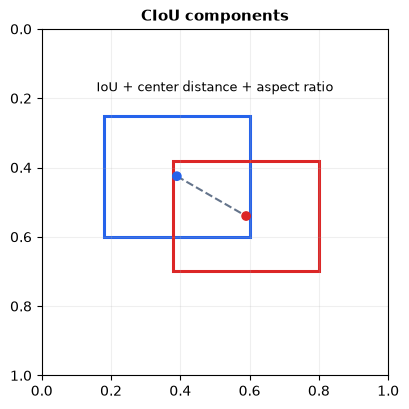

In [15]:
display_yolo_element_demo(4, 'ciou')

#### 5. MosaicなどのBoF/BoS

YOLOv4では、モデル構造だけでなく、学習時に使う工夫を強く重視します。その整理として、論文ではBag of Freebies（BoF）とBag of Specials（BoS）という見方が使われます。

Bag of Freebiesは、主に学習時だけ使い、推論時の計算を増やさずに精度を上げる工夫です。例として、Mosaic augmentation、label smoothing、DropBlock、Self-Adversarial Training（SAT）などがあります。推論時のnetworkに直接残らないものが多いため、推論速度を落とさずに学習を改善できます。

Bag of Specialsは、推論時の構造にも入るが、精度向上が大きい工夫です。YOLOv4文脈ではSPPやPAN、Mishなどがこの側に近い要素として扱われます。推論コストは少し増える可能性がありますが、検出品質を上げるために採用します。

Mosaicは、YOLOv4の代表的なBoFです。4枚の画像を切り貼りして、1枚の学習入力を作ります。

$$
I_{mosaic}=combine(I_1,I_2,I_3,I_4)
$$

このとき、画像だけでなくbboxアノテーションも同じ変換に合わせて移動・拡大縮小します。つまり、4枚分の物体、背景、スケール、配置が1枚の入力に混ざります。

```text
画像1 + bbox1     画像2 + bbox2
画像3 + bbox3     画像4 + bbox4
        -> 1枚のmosaic画像 + 変換後bbox
```

Mosaicの効果は、単に画像を4枚並べることではありません。1回のforwardで多様な背景と物体サイズを見せられるため、小さい物体、密集物体、通常とは違う位置にある物体への頑健性を上げやすくなります。また、batch sizeが小さい環境でも、1枚の入力内に複数画像由来の統計が入るため、学習の多様性を補えます。

YOLOv4を理解するときは、CSPDarknet53やSPP/PANのようなnetwork部品だけでなく、MosaicやCIoUのような学習側の工夫も同じくらい重要です。YOLOv4の特徴は、単一の新しいheadではなく、backbone、neck、loss、augmentationをまとめて調整した点にあります。


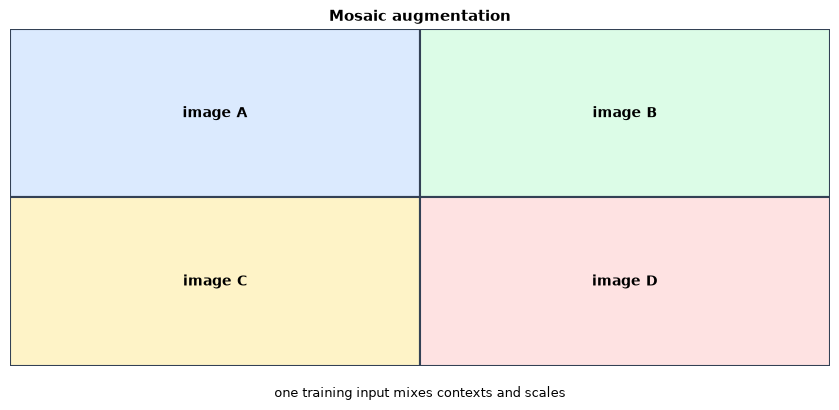

In [16]:
display_yolo_element_demo(4, 'mosaic')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

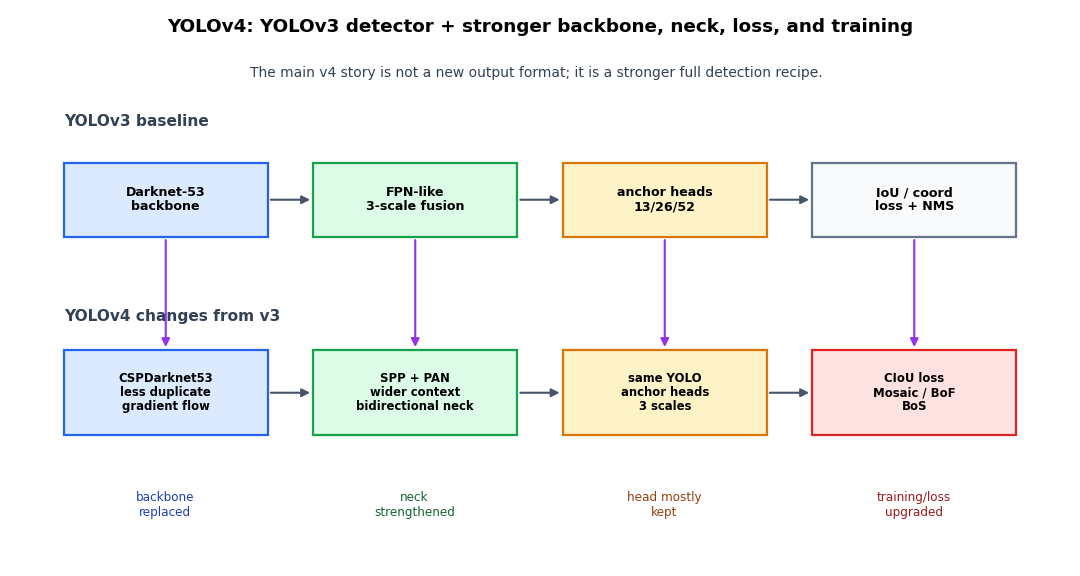

In [17]:
display_yolo_technology_demo(4)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(4, ['--mode', 'infer', '--image', 'images/sample.jpg', '--config', 'path/to/yolov4.cfg', '--weights', 'path/to/yolov4.weights'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOv5 (2020)

### アーキテクチャ全体像

YOLOv5は、論文上の単一アルゴリズムというより、PyTorchで学習、評価、推論、exportまでを扱いやすくした実装体系として大きな影響を持ちます。初期のYOLOv5ではFocus層で空間情報をチャンネル方向へ移し、CSP系backboneとPAN-FPN neck、anchor based headを組み合わせます。実務では、データセットyaml、学習CLI、重み管理、ONNX/TensorRT exportまでが一体化したことが重要です。

YOLOv5は、モデル構造だけでなく「実験から配備までの道具立て」が主役になります。v1〜v4では論文上の構造差分やDarknet形式を追っていましたが、v5ではPyTorch上でデータセット定義、学習、推論、exportを同じ流れで扱えることが重要です。

```text
data.yaml + images/labels
  -> train.py / YOLO API
  -> weights.pt
  -> predict / val
  -> ONNX, TensorRT, CoreML 等へ export
```

**新しく加わった技術:** PyTorch実装体系、PAN-FPN、AutoAnchor、学習・推論・export API。

出典: [公式/著者実装](https://github.com/ultralytics/yolov5)

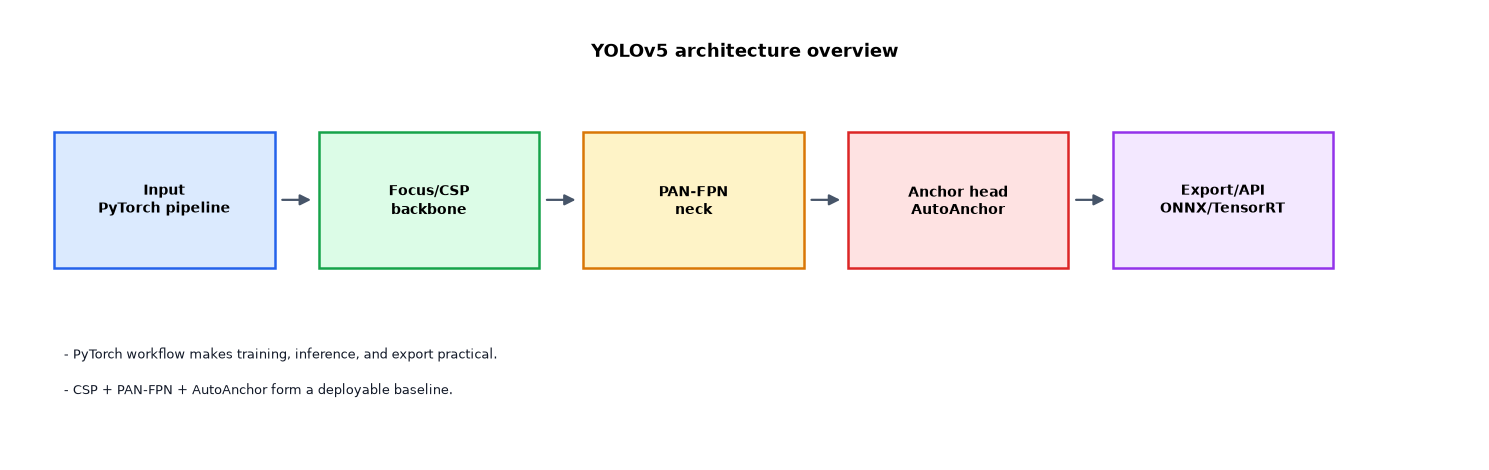

In [4]:
display_yolo_architecture(5)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. PyTorch実装体系

YOLOv5の大きな影響は、検出器をPyTorch上で学習・推論・評価・exportまで一貫して扱いやすくしたことです。Darknet形式のcfg/weightsを手で扱う流れから、Python APIとCLIで実験を回す流れへ移りました。技術要素としてはアルゴリズム単体ではなく、実務上の再現性と配備性に効いています。

$$
Dataset \rightarrow Train \rightarrow Validate \rightarrow Predict \rightarrow Export
$$

ここでの「実装体系」は、研究上は地味に見えますが実務では大きな差です。同じ重みを学習、評価、推論、exportまで流せると、モデル比較の条件を揃えやすくなります。古いDarknet系のようにcfg、weights、外部スクリプトを別々に管理するより、実験の再現と配備の手順が短くなります。


#### 2. PAN-FPN

YOLOv5のneckも、複数解像度の特徴を混ぜて3つの検出headへ渡すための構造です。流れとしてはYOLOv4のPANと同じく、上位の意味情報を高解像度側へ戻すtop-down経路と、高解像度側の位置情報を低解像度側へ返すbottom-up経路を持ちます。

$$
F^{out}_s = fuse(F^{backbone}_s, upsample(F^{out}_{s+1}), downsample(F^{out}_{s-1}))
$$

v4のSPP + PANとの違いは、主役が「新しいneck概念」ではなく、UltralyticsのPyTorch実装内で扱いやすいPAN-FPNとして整理された点です。YOLOv4では、深い特徴にSPPを入れて広い文脈を足し、その後PANで双方向に特徴を流す、という説明が中心でした。YOLOv5でも初期モデルではSPP/SPPF系の文脈集約を使いますが、教材上ここで強調したい差分は、v4で導入されたSPP+PANの考え方を、PyTorchのモデル定義、学習CLI、export可能な実装体系に組み込んだことです。

構造としては、YOLOv5のPAN-FPNもconcatを多用します。concat直後はchannel数が増えるため、その後の畳み込みで特徴を混ぜ、必要なchannel数へ整理します。つまり、v4と同じく「複数scaleを混ぜるneck」ですが、v5ではそれが実務パイプラインの中で標準部品として使いやすくなった、という位置づけです。

このため、この小節ではv4の4-2と同じ構造図を繰り返しません。PAN/FPNの特徴の流れ自体は4-2の図を参照し、ここでは「同じ系統のneckをPyTorch実装・学習CLI・export可能なモデル定義に組み込んだ」ことをv5側の差分として扱います。

整理すると、次のように見ると分かりやすいです。

| 観点 | YOLOv4 | YOLOv5 |
|---|---|---|
| neckの考え方 | SPPで文脈追加 + PANで双方向融合 | PAN-FPNとしてPyTorchモデル内に整理 |
| 実装 | Darknet系 | PyTorch / Ultralytics |
| 強調点 | 速度精度比を上げる構造・学習recipe | 学習、推論、exportまで含む使いやすい実装体系 |
| head | anchor-based 3 scale | anchor-based 3 scale |


#### 3. AutoAnchor

独自データではbboxの形状分布がCOCOと異なることがあります。AutoAnchorは、現在のanchorがそのデータセットに合っているかをまず評価し、合っていなければanchorを作り直す仕組みです。YOLOv2の「学習データのbbox幅高さをk-meansでクラスタリングしてanchorを決める」という考え方を、実務の学習パイプラインに組み込んだものと見ると理解しやすいです。

流れは大まかに次の通りです。

```text
1. 学習データの正解bboxから width, height を集める
2. 既存anchorが各bboxにどれくらい合うかを評価する
3. 合っていればそのまま使う
4. 合っていなければ k-means 系の方法でanchor候補を作り直す
5. 必要に応じて追加探索でanchorを少し改善する
```

ここで見ているのはbboxの中心位置ではなく、形、つまり `(w, h)` です。ある正解bbox `box` に対して、複数のanchor `anchor_a` との形の近さを比べます。概念的には次のように書けます。

$$
fitness = mean(\max_a IoU(box, anchor_a))
$$

この式は、次の意味です。

1つの正解bboxに対して、すべてのanchorと形のIoUを計算します。

```text
IoU(box, anchor_1) = 0.42
IoU(box, anchor_2) = 0.78
IoU(box, anchor_3) = 0.31
```

このbboxに一番合うanchorは `anchor_2` なので、このbboxの値は次になります。

```text
max_a IoU(box, anchor_a) = 0.78
```

これを全bboxについて行い、平均したものが上の `fitness` です。つまり、`fitness` が高いほど「各bboxに対して、どれか1つは形が近いanchorがある」ことを意味します。逆に低ければ、既存anchorではデータセットのbbox形状をうまく覆えていないため、anchorを作り直す必要があります。

実装上はIoUそのものだけでなく、bboxとanchorの幅比・高さ比に基づく指標も使われます。ただし直感は同じです。AutoAnchorは、各正解bboxに対して近いanchorがあるかを測り、足りなければデータセットに合わせてanchor集合を再設計するための機能です。

anchorが合っていないと、モデルは最初から不利な基準箱を補正し続けることになります。たとえば細長い物体ばかりのデータに、COCO向けの平均的なanchorを使うと、bbox回帰の負担が大きくなります。AutoAnchorは、学習前にこの不一致を検出し、必要ならanchorをデータに合わせる実務的な仕組みです。


#### 4. 学習・推論・export API

学習済み重みを推論し、ONNXやTensorRTへexportするところまで同じ操作体系で扱えることが、実務では大きな差になります。モデルの構造だけではなく、配備までの摩擦が検出器の使いやすさを決めます。

$$
weights.pt \rightarrow ONNX \rightarrow TensorRT / OpenVINO / CoreML
$$

exportまで同じAPIで扱えることは、モデル選択にも影響します。研究用に高精度でも、ONNXやTensorRTへ変換しにくい構造では現場に載せにくくなります。YOLOv5以降のUltralytics系では、学習済み重みをどの推論環境へ持っていけるかが、モデルの価値の一部になります。


### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(5, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'yolov5nu.pt', '--save'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOX (2021)

### アーキテクチャ全体像

YOLOXは、番号付きのYOLOv6ではありませんが、YOLO系列の重要な派生モデルです。位置づけとしては、YOLOv3系のone-stage detectorを2021年時点の設計へ近代化したモデルと見ると分かりやすいです。具体的には、anchor boxを使わないanchor-free head、分類とbbox回帰を分けるdecoupled head、そしてSimOTAによる動的label assignmentを組み合わせます。

YOLOv5が「PyTorchで扱いやすい実装体系」として大きな影響を持った一方で、YOLOXは検出headと学習時の正例割当をかなり明確に刷新しました。そのため、この教材ではv5の後、YOLOv6の前に置きます。以降のYOLOv6/v8などで出てくるanchor-free、decoupled head、動的割当を読むとき、YOLOXが前段の文脈になります。

```text
YOLOv3/v5系の流れ:
  anchor box を置く
  coupled head で class と bbox をまとめて扱う
  static または比較的固定的な割当

YOLOX:
  anchor-free head
  decoupled head
  SimOTA dynamic label assignment
```

**新しく加わった技術:** anchor-free head、decoupled head、SimOTA、強いaugmentationを前提にした学習recipe。

出典: [論文](https://arxiv.org/abs/2107.08430) / [公式実装](https://github.com/Megvii-BaseDetection/YOLOX)


### 新技術の要素ごとの説明

YOLOXでは、v2〜v5で使われていたanchor box前提のheadから離れます。ここでは、YOLOXを理解するために必要な3つの要素を分けて見ます。

#### 1. anchor-free head

YOLOXでは、各grid pointに事前定義したanchor boxの幅・高さを置きません。特徴マップ上の点を基準にし、その点からbboxの四辺までの距離、またはbbox座標を直接回帰します。

```text
anchor-based:
  grid point + anchor box width/height
  -> anchor box からのずれを予測

anchor-free:
  grid point / anchor point
  -> bboxそのもの、または四辺までの距離を予測
```

ここで注意したいのは、YOLOv2で出てきた `anchor` と、近年の説明で出てくる `anchor point` は同じものではない、という点です。YOLOv2のanchorは、正確には `anchor box` で、各grid pointに置く事前の箱の幅・高さです。一方、anchor-freeでいうanchor pointは、bboxを復元するための基準点であり、幅・高さを持つ候補箱ではありません。

なので「anchorが点になった」というより、**anchor boxという箱の事前分布を使う方式**から、**anchor pointという基準点からboxを復元する方式**へ寄った、と理解するとよいです。

これにより、データセットごとにanchor形状を調整する負担が減ります。一方で、どのgrid pointを正例にするかがより重要になります。そこで後述のSimOTAのようなlabel assignmentが効いてきます。


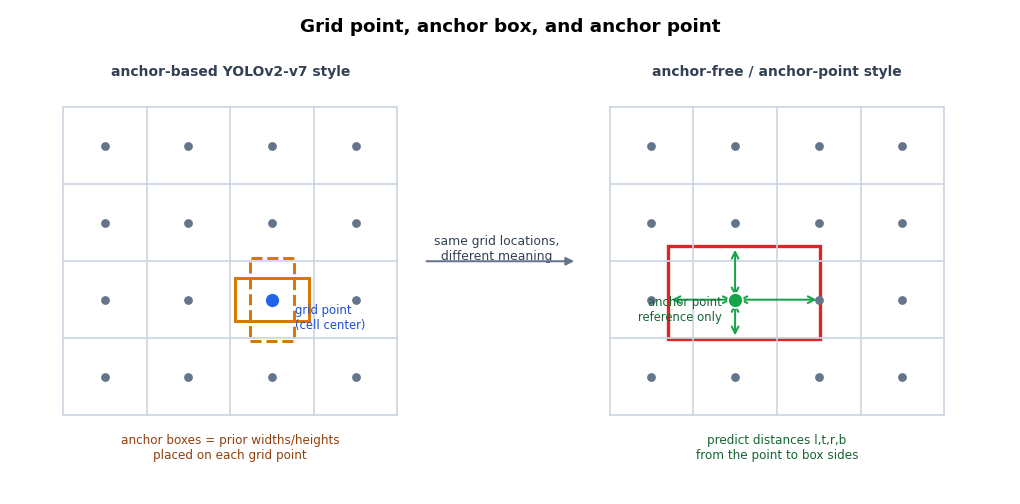

In [ ]:
display_yolo_element_demo(6, 'anchor_point_grid')

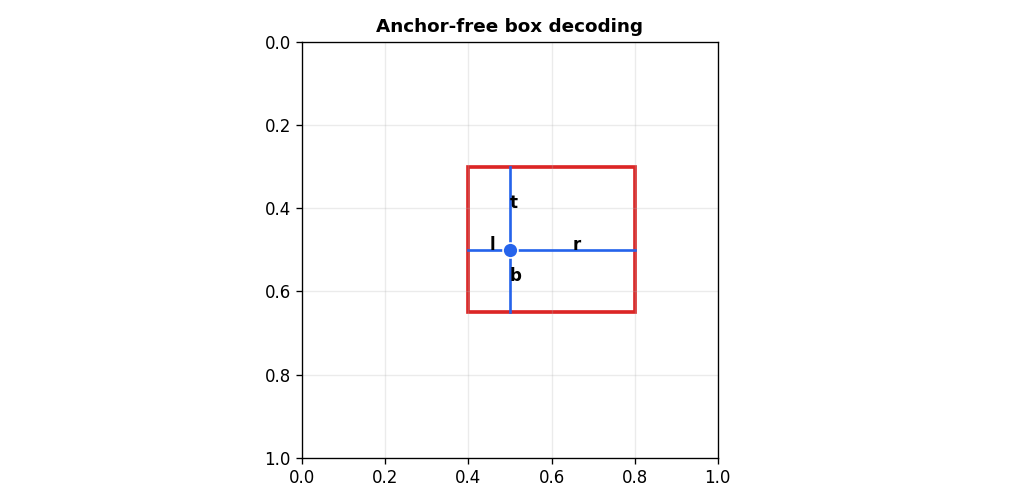

In [ ]:
display_yolo_element_demo(8, 'anchor_free')

#### 2. decoupled head

YOLOXは、分類とbbox回帰を同じheadでまとめて処理するのではなく、途中からbranchを分けます。分類branchは「何があるか」を、bbox branchは「どこにあるか」を主に担当します。

ここでいう「分ける」は、bboxの `x,y,w,h` を別々のbranchに分ける、という意味ではありません。共有特徴 `F` を受け取ったあと、**classを出すbranch**、**bboxを出すbranch**、**objectnessを出すbranch** に分けます。bbox branchの中では、bbox回帰に必要な4値をまとめて出します。

$$
F_{shared}=Stem(F)
$$

$$
Y_{cls}=Head_{cls}(F_{shared}) \in \mathbb{R}^{H\times W\times C}
$$

$$
Y_{reg}=Head_{reg}(F_{shared}) \in \mathbb{R}^{H\times W\times 4}
$$

$$
Y_{obj}=Head_{obj}(F_{shared}) \in \mathbb{R}^{H\times W\times 1}
$$

`C` はclass数です。COCOなら `C=80` なので、各grid pointは最終的に `4 + 1 + 80` 個の情報を持ちます。ただし、それらを1本のheadで一気に出すのではなく、途中のConv blockをclass用とregression用に分けてから出す、というのがdecoupled headです。

YOLOXのbbox回帰は、特徴マップ上のgrid pointを基準にしてbboxを復元します。grid pointを `(g_x,g_y)`、strideを `s`、bbox branchの出力を

$$
(t_x,t_y,t_w,t_h)
$$

とすると、典型的には次のようにdecodeします。

$$
b_x=(t_x+g_x)s, \quad b_y=(t_y+g_y)s
$$

$$
b_w=\exp(t_w)s, \quad b_h=\exp(t_h)s
$$

ここで `(b_x,b_y)` は予測bboxの中心、`(b_w,b_h)` は幅と高さです。YOLOv2のようにanchor boxの幅・高さ `(p_w,p_h)` を掛けるのではなく、strideを基準にサイズを復元する点がanchor-free寄りです。

最終的な候補は、bbox branchから位置、objectness branchから「物体らしさ」、class branchから「どのclassらしいか」を受け取ります。

$$
score_c = \sigma(Y_{obj}) \cdot \sigma(Y_{cls,c})
$$

つまり、decoupled headで分けているのは、次の3つです。

| branch | 出力 | 役割 |
|---|---:|---|
| bbox / regression | `4` | bbox中心と幅・高さを復元する |
| objectness | `1` | その点に物体があるかを見る |
| classification | `C` | 物体がどのclassかを見る |

同じ特徴を完全に共有すると、カテゴリ識別に必要な特徴と、位置を精密に合わせるための特徴が衝突することがあります。decoupled headでは、共有特徴を受け取った後、class branchとbox branchへ分けることで、この衝突を弱めます。

```text
shared feature
  -> class branch: class score C
  -> box branch: bbox regression 4
  -> objectness branch: objectness 1
```

この設計は、後のYOLOv6などにもつながる重要な流れです。


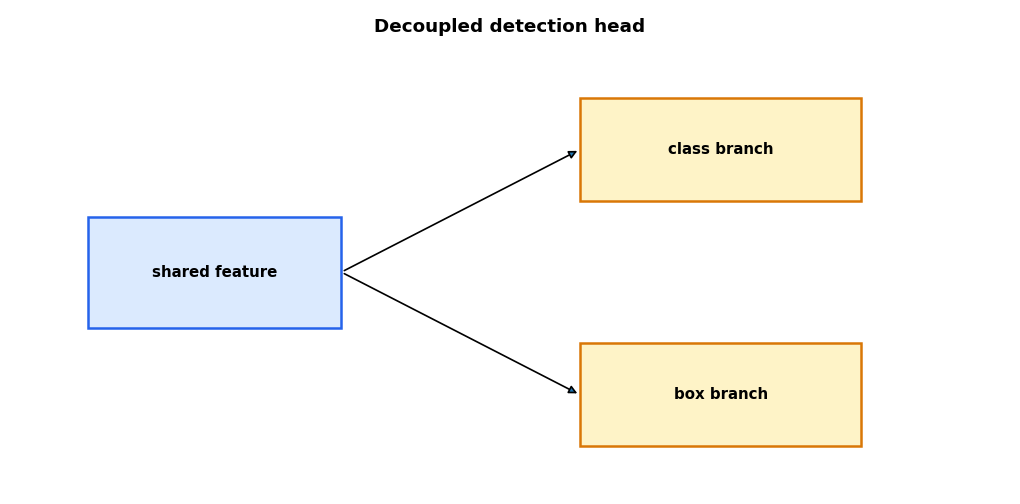

In [ ]:
display_yolo_element_demo(6, 'decoupled')

#### 3. SimOTA (Simplified Optimal Transport Assignment)

SimOTAは、YOLOXで使われた動的label assignmentです。目的は、各正解bboxに対して、どの候補点を正例にするかを決めることです。

まず、正解bboxを `g_i`、予測候補を `j` とします。候補 `j` は、bbox branchから予測bbox `b_j`、objectness branchから物体らしさ `o_j`、class branchからclass score `p_{j,c}` を出します。

SimOTAでは、候補ごとにclassification cost、bbox cost、center priorを組み合わせたcostを作ります。YOLOXの実装に近い形で書くと、正解 `i` と候補 `j` のcostは次です。

$$
Cost_{ij}=L^{cls}_{ij}+3.0L^{box}_{ij}+100000\cdot \mathbb{1}_{\text{not center}_{ij}}
$$

ここで、costが低い候補ほど、その正解bboxを担当する候補として良いと判断します。

##### classification cost

YOLOXでは、class scoreだけでなく objectness も掛け合わせて「そのclassの物体らしさ」を見ます。正解classを `c_i` とすると、候補 `j` のそのclassに対する予測scoreは概念的に次です。

$$
q_{j,c}=\sigma(o_j)\sigma(p_{j,c})
$$

実装では、このscoreに平方根をかけたものをBCEへ入れます。

$$
L^{cls}_{ij}=BCE\left(\sqrt{q_j},\ y_i\right)
$$

`y_i` は正解classだけが1になるone-hot vectorです。つまり、正解classのscoreが高く、他classのscoreが低い候補ほど `L^{cls}` は小さくなります。

##### bbox cost

bbox costは、予測bbox `b_j` と正解bbox `g_i` のIoUから作ります。

$$
u_{ij}=IoU(b_j,g_i)
$$

YOLOXでは、典型的に次の形を使います。

$$
L^{box}_{ij}=-\log(u_{ij}+\epsilon)
$$

IoUが1に近いほど `-log(IoU)` は0に近づき、IoUが低いほど大きくなります。つまり、正解bboxとよく重なる予測ほどcostが小さくなります。

##### center prior / penalty

候補点が正解bboxの中、または正解中心付近の領域にあるかも見ます。候補点を `a_j=(x_j,y_j)`、正解bboxの中心を `c_i=(c_x,c_y)`、strideを `s`、中心領域の半径係数を `r` とすると、中心領域は概念的に次のように置けます。

$$
|x_j-c_x| < rs, \quad |y_j-c_y| < rs
$$

YOLOXでは、候補がbbox内や中心領域の条件を満たすかを使って候補を絞り、中心条件を満たさない候補には非常に大きい罰則を加えます。

$$
penalty_{ij}=100000\cdot \mathbb{1}_{\text{not center}_{ij}}
$$

これは「遠い候補点が、たまたま回帰で良いbboxを出したからといって、その物体の担当になりすぎないようにする」ための項です。`L_box` は出てきたbboxを評価し、center priorはその予測を出した候補点の場所を評価します。

##### dynamic k matching

さらに、SimOTAでは正解物体ごとの正例数を固定しません。各正解 `i` について、IoUが高い上位候補を見て、そのIoUの和から正例数 `k_i` を決めます。

$$
k_i=\max\left(1,\left\lfloor\sum_{j\in TopK(i)} IoU(b_j,g_i)\right\rfloor\right)
$$

そのうえで、正解 `i` に対して `Cost_{ij}` が小さい候補を `k_i` 個選びます。良い候補が多い物体には複数の正例を与え、良い候補が少ない物体には少なめにします。このため dynamic assignment と呼ばれます。

```text
各GTについて:
  1. 候補点をbbox内/中心付近で絞る
  2. 各候補の Cost = class + 3*box + center penalty を計算
  3. IoU上位候補から dynamic k を決める
  4. costが低い候補を k 個だけ正例にする
```

YOLOXでSimOTAが重要なのは、anchor-free化により「どの点に物体を担当させるか」がより重要になったからです。anchor boxの候補形状に頼らないぶん、学習時の正例選びが検出品質に強く効きます。


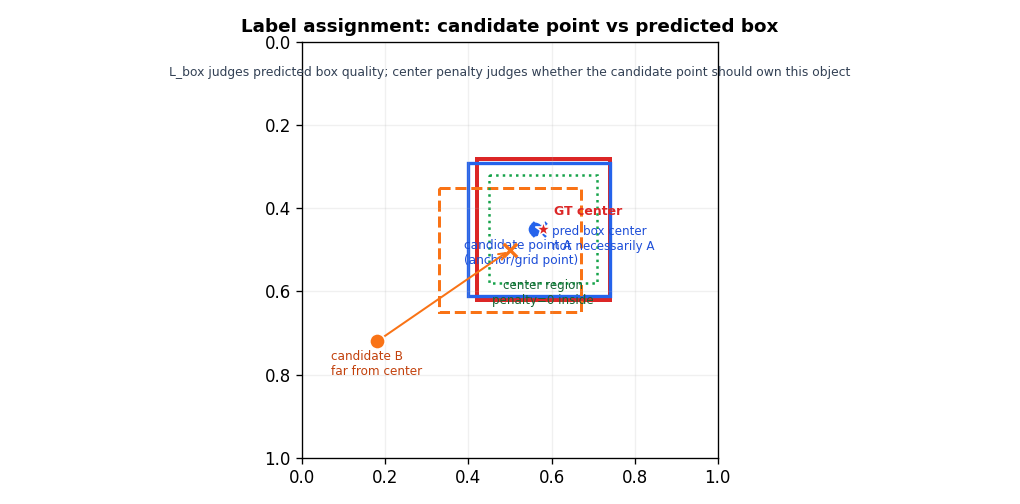

In [ ]:
display_yolo_element_demo(6, 'assignment')

### 実際の推論体験

YOLOXは `run_yolo("yolox", ...)` から呼び出せるようにしています。ただし、YOLOX本体は公式リポジトリ側の環境に依存するため、backendは `external` として扱います。つまり、Notebook側では共通の入口を使い、実際の推論コマンドは `--command` に渡します。

```python
run_yolo("yolox", [
    "--mode", "infer",
    "--image", "images/sample.jpg",
    "--weights", "path/to/yolox_s.pth",
    "--command",
    "python tools/demo.py image -f exps/default/yolox_s.py -c {weights} --path {image} --conf {conf} --nms {iou} --save_result",
])
```

この教材内では、YOLOXは「anchor-free head、decoupled head、SimOTAがYOLO系へ入ってきた重要な分岐」として扱います。後半の複数モデル比較でも、`VERSION = "yolox"` のように指定できます。


## YOLOv6 (2022)

### アーキテクチャ全体像

YOLOv6は、学習時と推論時の構造を分ける再パラメータ化を強く使います。学習時には3x3、1x1、identity/BNなど複数枝で表現力と最適化しやすさを確保し、推論時にはそれらを等価な単一畳み込みへ融合します。低遅延推論を重視する産業用途に寄せた設計です。

YOLOv6で見るべき点は、「学習しやすい構造」と「推論しやすい構造」を同じにしないことです。学習時は枝を増やして表現力と勾配の流れを確保し、配備時にはそれを単純な畳み込みへ畳み込みます。さらに、正例割当ではYOLOXのSimOTAの流れを受けつつ、後期版ではTask Aligned Learning (TAL) 系の考え方で、class scoreとbbox品質の両方が高い候補を重視します。

**新しく加わった技術:** RepVGG系の再パラメータ化、TAL系割当、産業配備向け効率設計。

出典: [公式/著者実装](https://github.com/meituan/YOLOv6) / [論文](https://arxiv.org/abs/2209.02976)


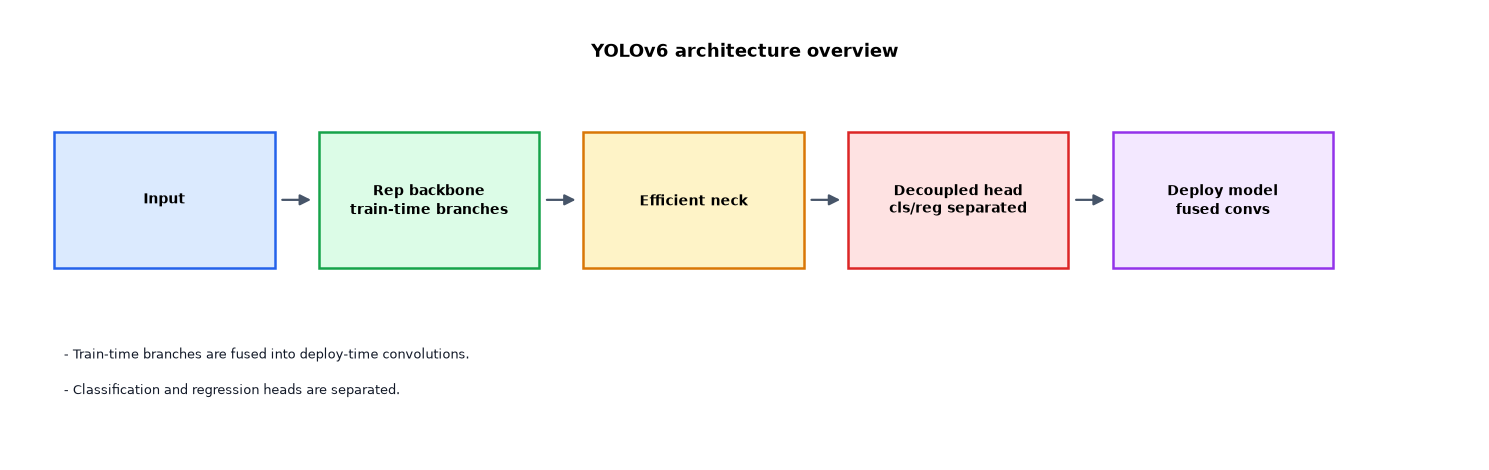

In [2]:
display_yolo_architecture(6)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. 再パラメータ化

学習時には3x3、1x1、identity/BNなど複数枝を持ち、推論時には等価な1つの畳み込みへ融合します。学習しやすい構造と推論しやすい構造を分けるのがポイントです。

$$
Conv_{deploy}(x)=Conv_{3x3}(x)+Conv_{1x1}(x)+BN(x)
$$
1x1 kernelやidentityは3x3 kernelの中央に埋め込んで足し合わせます。

この式は出力を足しているように見えますが、実装上は各枝の畳み込みkernelとbiasを等価な1つのkernelへ変換します。1x1 kernelは3x3の中央に埋め込み、identityは中心が1のkernelとして扱い、BNのscale/shiftも畳み込みへ吸収します。結果として、学習時は多枝、推論時は単枝という形になります。


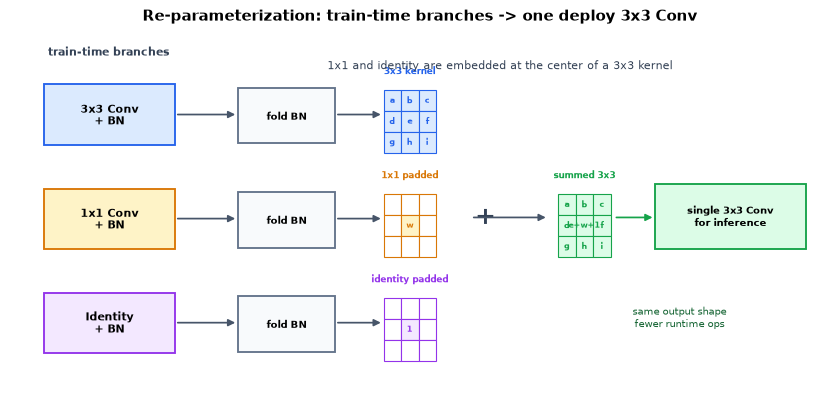

In [3]:
display_yolo_element_demo(6, 'reparam')

#### 2. TAL系割当

YOLOv6でも、物体検出の学習では「どの予測候補をどの正解bboxの正例として扱うか」を決める必要があります。この処理を label assignment、または正例割当と呼びます。YOLOXではSimOTAとして説明した部分です。

YOLOv6でここを読むときの主役は、SimOTAそのものというより **Task Aligned Learning (TAL)** です。TALは、候補の良さを「分類として自信があるか」と「bboxとして正解に合っているか」の両方で見ます。直感的には、class scoreだけ高くてもboxがずれている候補、boxだけ近くてもclass scoreが低い候補は避け、両方が揃った候補を正例にしたい、という考え方です。

典型的には、候補点 `p=(x,y)` からbboxを復元し、その予測bboxと正解bboxのIoUを計算します。

$$
box=(x-l,\ y-t,\ x+r,\ y+b)
$$

このbboxの中心は次です。

$$
center(box)=\left(\frac{x_1+x_2}{2},\frac{y_1+y_2}{2}\right)
$$

候補点は、予測bboxの中心そのものとは限りません。候補点は「その予測を出す特徴マップ上の基準位置」であり、予測bboxの中心はモデルが出した `l,t,r,b` や座標から後で決まります。したがって、center priorやcenter penaltyは「その場所の候補にこの物体を担当させるのが自然か」を見ており、`L_box` は「出てきたboxが正解bboxに近いか」を見ています。

| 項 | 見ている対象 | 役割 |
|---|---|---|
| `L_cls` | class score | 正解classを高く出しているか |
| `L_box` | 予測されたbbox | boxとして正解bboxに近いか |
| `penalty_center` | 予測を出した元の候補点 | その候補点にこの物体を担当させて自然か |

SimOTA風のcostで書くと、概念的には次のようになります。

$$
cost = L_{cls} + \lambda L_{box} + penalty_{center}
$$

各要素は、典型的には次のように計算します。実装ごとに細部は違いますが、直感はこの形です。

| 項 | 典型的な計算 | 小さいほど良い理由 |
|---|---|---|
| `L_cls` | `BCE(pred_class_score, target_class)` | 正解classを高く出している候補ほど小さい |
| `L_box` | `1 - IoU(pred_box, gt_box)` または `-log(IoU)` | 正解bboxと重なる候補ほど小さい |
| `penalty_center` | 候補点が正解bbox中心付近にない場合に加算 | 遠い点が無理に担当する候補を避ける |

TALでは、costを直接足すというより、分類scoreとIoUを掛け合わせた alignment metric を使います。

$$
alignment = s^\alpha u^\beta
$$

ここで `s` は正解classに対する予測score、`u` は予測bboxと正解bboxのIoUです。`alignment` が高い候補ほど、分類と位置合わせの両方が揃っています。YOLOv6では、このようなtask-alignedな候補を優先して正例にすることで、学習時の担当割り当てをより安定させます。


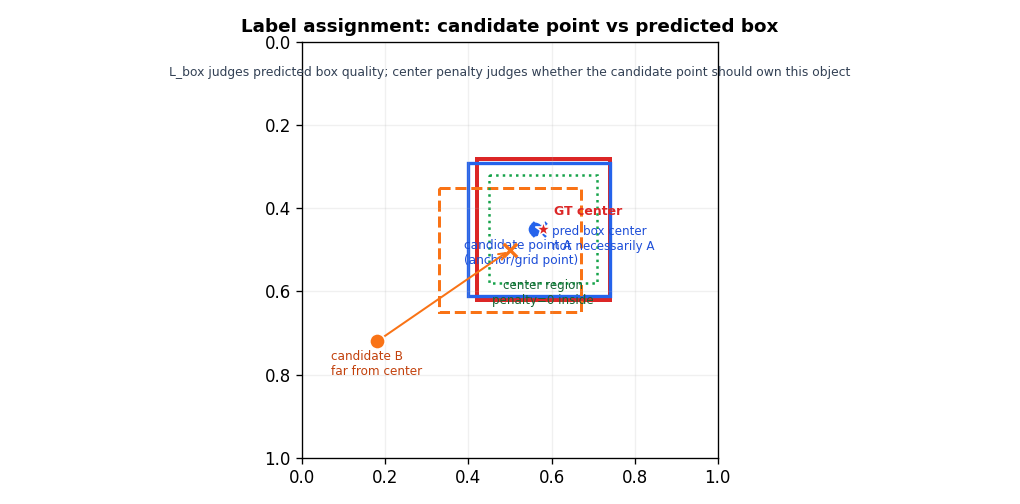

In [4]:
display_yolo_element_demo(6, 'assignment')

#### 3. 産業配備向け効率

YOLOv6は実測レイテンシを重視します。FLOPsが小さくても推論エンジンで遅い構造は避け、deploy時に単純な畳み込みへ畳み込める構造を選びます。

$$
latency \neq FLOPs\quad\text{なので、実測runtimeを設計対象にする}
$$

産業配備では、FLOPsの小ささだけでは不十分です。メモリアクセスが多い層、推論エンジンが最適化しにくい演算、後処理の重さは、実測レイテンシを悪化させます。YOLOv6の効率設計は、GPUやエッジ推論で実際に速く動く形へ寄せるためのものです。


In [ ]:
display_yolo_element_demo(6, 'efficiency')

### 図で確認する差分

上の要素別デモを通して、YOLOv6で重視された再パラメータ化、TAL系割当、配備効率の考え方を確認します。anchor-freeやdecoupled headの基礎はYOLOXで説明済みなので、ここではv6で特に見るべき差分に絞ります。


In [ ]:
display_yolo_technology_demo(6)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(6, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'path/to/model', '--command', 'python path/to/official/infer.py --weights {weights} --source {image}'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOv7 (2022)

### アーキテクチャ全体像

YOLOv7は、E-ELANによって特徴変換の経路を増やし、concatで統合することで表現の多様性と勾配の流れを保ちます。さらにモデルサイズを変えるときのscaling規則、再パラメータ化をどこに入れるかの計画、学習時だけ使う補助的な工夫を整理しています。検出headだけでなく、backbone内部でどのように特徴を流すかが性能に直結することを示した世代です。

YOLOv7は、特徴をどのように通し、どのように結合し、モデルサイズを変えても破綻しにくくするかに焦点があります。v6と同じく再パラメータ化を使いますが、どこに入れるかを構造全体と合わせて考える点が重要です。

**新しく加わった技術:** E-ELAN、モデルscaling、planned re-parameterization、trainable bag-of-freebies。

出典: [公式/著者実装](https://github.com/WongKinYiu/yolov7) / [論文](https://arxiv.org/abs/2207.02696)

In [ ]:
display_yolo_architecture(7)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. E-ELAN

E-ELANは複数の変換経路を作り、最後にconcatして特徴を集約します。深く広いネットワークで勾配経路が単調になりすぎないようにし、特徴の多様性を保ちます。

$$
Y = concat(F_1(X), F_2(X), \ldots, F_n(X))
$$

E-ELANでは、複数経路を作ることで同じ入力から異なる深さ・変換回数の特徴を得ます。concat直後はchannel数が増えるため、その後の畳み込みで混ぜ直して次のstageへ渡します。狙いは、単に層を深くするのではなく、特徴の多様性と勾配経路を保ったまま表現力を上げることです。


In [ ]:
display_yolo_element_demo(7, 'elan')

#### 2. モデルscaling

モデルを大きくするとき、depthだけ、widthだけを単純に増やすと、stage間の計算バランスが崩れます。YOLOv7ではblock構造に合わせてdepthとwidthを調整し、速度と精度の関係を保ちます。

$$
C' = \alpha C, \quad D' = \beta D
$$
ただし、stageごとのconcat幅やhead計算量も同時に見ます。

scalingは、モデルを `small` から `large` へ大きくするような場面で効きます。単純に全層のchannelを増やすと、concat後の幅やhead側の計算が急に重くなることがあります。YOLOv7では、blockの構造と結合位置を考慮しながら、depth、width、stage間のバランスを調整します。


In [ ]:
display_yolo_element_demo(7, 'scaling')

#### 3. planned re-parameterization

再パラメータ化はどこにでも入れればよいわけではありません。concatや残差構造との相互作用を考え、学習時の枝を推論時に正しく融合できる場所へ計画的に入れます。

$$
F_{train}^{multi-branch} \rightarrow F_{deploy}^{single-branch}
$$

再パラメータ化は便利ですが、残差やconcatの周辺に無計画に入れると、推論時に等価変換しにくくなります。planned re-parameterizationでは、学習時に枝を増やしても、deploy時にきれいに単純化できる位置を選びます。ここでも「学習時の表現力」と「推論時の単純さ」を分けて考えます。


In [ ]:
display_yolo_element_demo(7, 'reparam')

#### 4. trainable bag-of-freebies

補助headなど、学習時だけ使って推論時には消せる部品を入れます。推論コストを増やさずに深い層へ学習信号を追加する考え方です。

$$
L = L_{main} + \lambda L_{aux}
$$
推論時は $Head_{aux}$ を使いません。

trainable bag-of-freebiesは、データ拡張のような固定処理だけでなく、学習可能な補助moduleや補助headを含みます。主headだけでは届きにくい深い層へ追加のlossを与え、学習を助けます。推論時には補助部分を外すので、最終モデルの計算量を増やさないのがポイントです。


In [ ]:
display_yolo_element_demo(7, 'pgi')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

In [ ]:
display_yolo_technology_demo(7)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(7, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'path/to/model', '--command', 'python path/to/official/infer.py --weights {weights} --source {image}'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOv8 (2023)

### アーキテクチャ全体像

YOLOv8は、anchor based headからanchor-freeなdecoupled headへ移ります。特徴マップ上の点を基準に、bboxの左・上・右・下距離を予測し、anchorの幅高さ候補への依存を減らします。backbone/neckにはC2fなどの軽量な特徴再利用構造を使い、UltralyticsのAPIでは検出、segmentation、poseなどを同じ体系で扱います。

YOLOv8では、v2以降続いてきた「anchorの形を先に置く」考え方から離れます。特徴点そのものを基準にし、そこからbboxの4辺までの距離を出すため、anchorの幅高さをデータごとに調整する負担が減ります。ここから先の節では、head設計が anchor-based から anchor-free / end-to-end へ移っていく流れとして見ると理解しやすくなります。

**新しく加わった技術:** anchor-free decoupled head、C2f、DFLを含むbbox表現、タスク統合API。

出典: [公式/著者実装](https://github.com/ultralytics/ultralytics)

In [ ]:
display_yolo_architecture(8)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. anchor-free head

YOLOv8ではanchor形状を前提にせず、特徴点からbbox境界までの距離を予測します。anchorの幅高さがデータに合わない問題を避けやすくなり、head設計も単純になります。

$$
box=(x-l,\ y-t,\ x+r,\ y+b)
$$

anchor-freeでは、事前に決めた幅高さの候補箱を置かず、特徴点を基準にboxを復元します。たとえば点 `(x, y)` から左へ `l`、上へ `t`、右へ `r`、下へ `b` だけ離れた位置を予測します。anchor設計の手間は減りますが、どの点を正例にするか、距離をどう学習するかが重要になります。


In [ ]:
display_yolo_element_demo(8, 'anchor_free')

#### 2. decoupled head

分類とbbox回帰を分ける設計です。class branchはカテゴリ識別、box branchは位置とサイズの調整に集中できます。anchor-free化と組み合わせることで、近年の検出headらしい構造になります。

$$
P(class)=Head_{cls}(F), \quad (l,t,r,b)=Head_{box}(F)
$$

YOLOv8のdecoupled headは、anchor-free化と組み合わさることで意味がはっきりします。class branchは各特徴点がどのカテゴリらしいかを出し、box branchはその点からbbox境界までの距離を出します。objectnessを独立に持つ古いYOLO系とは出力の整理も変わるため、headの読み方も更新する必要があります。


In [ ]:
display_yolo_element_demo(8, 'decoupled')

#### 3. C2f

C2fはCSP系の特徴分割・結合をさらに軽量にし、中間特徴を多く再利用します。計算量を抑えながらgradient flowと特徴再利用を確保するblockです。

$$
Y = concat(X_1, B_1(X_2), B_2(B_1(X_2)), \ldots)
$$

C2fでは、中間blockの出力を複数取り出してconcatするため、特徴の再利用が増えます。concatした直後はchannelが増えますが、後段の畳み込みで混ぜて調整します。CSP系の「分けて、一部を変換し、最後に結合する」発想を、より軽く多段にしたものとして見ると理解しやすいです。


In [ ]:
display_yolo_element_demo(8, 'c2f')

#### 4. DFLを含むbbox表現

YOLOv8系ではbbox距離を単一の連続値として直接出すだけでなく、離散bin上の分布として学習するDFLの考え方を使います。期待値として距離を復元するため、bbox回帰が安定しやすくなります。

$$
d = \sum_i i \cdot P(i)
$$

DFLでは、距離を1つの数として直接当てる代わりに、近いbinへ確率を分配します。たとえば距離が `5.3` なら、5付近と6付近のbinに重みを持つ分布として学習できます。これにより、bbox境界の細かな位置を分類問題に近い形で安定して学習できます。


In [ ]:
display_yolo_element_demo(8, 'dfl')

#### 5. タスク統合API

検出、segmentation、poseなどを同じAPIで扱えることで、同じデータ管理・推論・exportの流れを使えます。アルゴリズムだけでなく、タスク間の開発体験を統合した点が重要です。

$$
model.task \in \{detect, segment, pose, classify, obb\}
$$

タスク統合APIは、単に関数名が同じという話ではありません。入力前処理、重み管理、推論結果の表現、可視化、exportを共通化できるため、検出モデルからsegmentationやposeへ試行を広げやすくなります。研究上の構造差分とは別に、実務で試す速度を上げる要素です。


In [ ]:
display_yolo_element_demo(8, 'pipeline')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

In [ ]:
display_yolo_technology_demo(8)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(8, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'yolov8n.pt', '--save'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLO-NAS (2023)

### アーキテクチャ全体像

YOLO-NASは、YOLOv8と同じ2023年の文脈で登場したYOLO系の派生モデルです。名前の通り、中心にある考え方は **Neural Architecture Search (NAS)** です。つまり、人間が「このblockを何層積む」「ここでchannelを増やす」と手で設計するだけでなく、精度と速度のトレードオフが良くなる構造を探索して決めます。

ここで重要なのは、YOLO-NASが「YOLOv8の次の番号付き公式後継」ではないことです。YOLO系列で蓄積されたone-stage detectorの設計を土台にしつつ、アーキテクチャ探索と配備効率を強く意識した実用モデル群として見ると分かりやすいです。

```text
手設計のYOLO:
  人間が backbone / neck / head の構造を決める
  実験で良い構造を選ぶ

YOLO-NAS:
  探索空間を用意する
  精度・速度・配備しやすさを見ながら候補構造を探索する
  Paretoの良いモデルを small / medium / large のように使う
```

**新しく加わった観点:** 手作業のblock設計だけでなく、探索によって実用的な速度・精度バランスを作ること。

出典: [SuperGradients/YOLO-NAS実装](https://github.com/Deci-AI/super-gradients) / [YOLO review](https://arxiv.org/abs/2304.00501)

### 新技術の要素ごとの説明

#### 1. NASによる構造探索

NASは、モデル構造そのものを探索対象にします。例えば、どのblockを使うか、どれくらいchannelを持たせるか、どこを軽くするか、といった設計選択を候補として持ちます。探索では、精度だけでなく、推論速度や実装しやすさも評価します。

物体検出では、backboneだけ速くても、neckやhead、後処理が重ければ実用上は遅くなります。YOLO-NASのポイントは、検出モデル全体として使いやすい構造を探索するところにあります。

#### 2. 速度と精度のPareto frontier

高速モデルの比較では、単純に「一番精度が高い」だけでは足りません。少し精度が低くても大幅に速いモデル、少し遅くても精度がかなり高いモデルなど、用途によって良い選択は変わります。

このとき、あるモデルが「別のモデルより遅く、かつ精度も低い」なら選ぶ理由が薄くなります。逆に、速度と精度のどちらかで明確な利点がある候補群を Pareto frontier として見ると、実用上の選択がしやすくなります。

#### 3. 配備を意識したモデル設計

YOLO-NASは、研究用の大きなモデルだけでなく、実際に推論環境へ載せることを意識したモデル群として扱われます。GPU、エッジデバイス、量子化、推論エンジンなどを考えると、理論上のFLOPsだけでは速度を説明しきれません。

この意味で、YOLO-NASはYOLOv6の「実測レイテンシを重視する」流れとも近いですが、v6が再パラメータ化などの具体的設計を押し出したのに対し、YOLO-NASは構造探索そのものを前面に出している点が違います。

### 実際の推論体験

YOLO-NASは `run_yolo("yolo-nas", ...)` から呼び出せるようにしています。ただし、実際の推論はSuperGradientsなど対応する実装環境に依存するため、backendは `external` として扱います。

```python
run_yolo("yolo-nas", [
    "--mode", "infer",
    "--image", "images/sample.jpg",
    "--weights", "path/to/yolo_nas_s.pth",
    "--command",
    "python path/to/yolo_nas_infer.py --weights {weights} --source {image} --conf {conf} --iou {iou}",
])
```

後半の複数モデル比較でも、`VERSION = "yolo-nas"` のように指定できます。`--command` の中身は、使用するSuperGradients版や自作推論スクリプトに合わせて置き換えてください。


## RT-DETR (2023)

### アーキテクチャ全体像

RT-DETRは、名前の通りYOLOではなく **Real-Time DEtection TRansformer** です。ただし、リアルタイム物体検出という同じ土俵でYOLO系と比較される重要なモデルなので、この時系列に入れておく価値があります。

YOLO系は、多数の候補bboxをdenseに出し、最後にNMSで重複を消す流れが基本でした。一方、DETR系は object query を使い、集合予測として物体を直接出します。学習ではHungarian matchingにより、予測と正解を1対1に対応づけます。この設計により、原理的にはNMSなしで検出できます。

```text
YOLO系:
  dense prediction
  many candidate boxes
  NMSで重複除去

RT-DETR:
  transformer + object queries
  one-to-one matching
  NMS-free end-to-end detection
```

**新しく加わった観点:** YOLO的なdense headではなく、DETR系のquery-based / end-to-end / NMS-freeな検出をリアルタイム化したこと。

出典: [論文](https://arxiv.org/abs/2304.08069) / [実装](https://github.com/lyuwenyu/RT-DETR)

### 新技術の要素ごとの説明

#### 1. NMS-freeなend-to-end検出

YOLOでは、近い位置に似たbboxが大量に出るため、最後にNMSで重複を消します。NMSは実用的ですが、閾値や実装に依存し、後処理として推論パイプラインに残ります。

RT-DETRは、DETR系の集合予測として物体を出すため、予測と正解を1対1に対応づける方向で学習します。重複候補を後から消すのではなく、そもそも重複しにくい予測集合を作る、という発想です。

#### 2. efficient hybrid encoder

標準的なTransformerをそのまま検出に使うと、計算量が大きくなりやすいです。RT-DETRでは、multi-scale featureを処理するencoderを効率化し、同じscale内の情報交換とscale間の融合を分けて考えます。

YOLOのneckがFPN/PANでmulti-scale featureを融合するのに対し、RT-DETRはTransformer的な表現力を使いながら、リアルタイム性を失わないようにencoderを設計している、と見ると分かりやすいです。

#### 3. query selectionとdecoder層数による速度調整

DETR系では、object queryが最終的な検出候補になります。RT-DETRでは、decoderへ渡すqueryの質を高めるためのquery selectionを使います。良い初期queryを選べるほど、decoderが少ない層数でも有効な予測を作りやすくなります。

また、decoder層数を変えることで速度と精度を調整できます。これは、同じ系統のモデルを用途に合わせて軽くしたり重くしたりするための実用的なつまみです。

### 実際の推論体験

RT-DETRはYOLOではありませんが、リアルタイム検出の比較対象として `run_yolo("rt-detr", ...)` から呼び出せるようにしています。実際の推論はRT-DETRの公式実装や対応フレームワークに依存するため、backendは `external` として扱います。

```python
run_yolo("rt-detr", [
    "--mode", "infer",
    "--image", "images/sample.jpg",
    "--weights", "path/to/rtdetr_model.pth",
    "--command",
    "python path/to/rtdetr_infer.py --weights {weights} --source {image} --conf {conf} --iou {iou}",
])
```

後半の複数モデル比較でも、`VERSION = "rt-detr"` のように指定できます。RT-DETRはNMS-freeなDETR系なので、YOLO系と比較するときは後処理や保存形式も合わせて確認してください。


## YOLOv9 (2024)

### アーキテクチャ全体像

YOLOv9は、推論経路を重くしすぎず、学習時にだけ追加の勾配情報を与えるPGIを導入します。深いネットワークや軽量モデルでは、入力から出力へ進む間に情報や勾配が弱くなり、学習が不安定になることがあります。PGIは補助的な経路で学習信号を制御し、推論時には不要な部分を外します。GELANはELAN系の効率的な特徴集約をさらに発展させた構造です。

YOLOv9は、推論時の形だけを見ると分かりにくい世代です。重要なのは、学習中にどのような勾配情報を主経路へ戻すかです。補助経路を使って学習を助け、推論時には外すため、最終的な推論コストを増やさずに学習の安定性を狙います。

**新しく加わった技術:** Programmable Gradient Information (PGI)、GELAN、推論時に消せる補助経路。

出典: [公式/著者実装](https://github.com/WongKinYiu/yolov9) / [論文](https://arxiv.org/abs/2402.13616)

In [ ]:
display_yolo_architecture(9)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. PGI

Programmable Gradient Informationは、学習時に補助経路を使って主経路へ有効な勾配情報を流す設計です。深いネットワークや軽量モデルでは情報が失われやすいため、推論時の構造を重くせずに学習だけを助けます。


$$
\nabla W = \nabla W_{main} + \lambda \nabla W_{aux}
$$

ここで補助経路は、推論結果を直接増やすためではなく、学習中に主経路へより有用な勾配を返すために使います。軽量モデルでは層を通る間に情報が弱くなりやすいため、補助的な監督を入れることで、最終的に残す推論経路を学習しやすくします。

In [ ]:
display_yolo_element_demo(9, 'pgi')

#### 2. GELAN

GELANはELAN系の複数経路集約を発展させた構造です。複数の変換経路で特徴を作り、concatで統合することで、表現力と勾配の流れを両立します。

$$
Y = concat(F_1(X), F_2(X), \ldots, F_n(X))
$$

GELANでは、複数経路の出力をconcatして特徴を集約します。concat後はchannelが増えるため、後続の畳み込みで必要な幅へ整理します。ELAN系の狙いは、深くしても勾配が単調に1本化しないようにし、異なる変換段階の特徴を同時に使えるようにすることです。


In [ ]:
display_yolo_element_demo(9, 'elan')

#### 3. 補助経路の除去

PGIの補助枝は推論時に必要な演算ではありません。学習時にだけlossと勾配を追加し、deploy時には本体経路だけを残します。

$$
Model_{train}=Backbone+Head_{main}+Head_{aux}
$$
$$
Model_{infer}=Backbone+Head_{main}
$$

この考え方は、v6/v7の再パラメータ化と似た発想を学習経路に適用していると見ると分かりやすいです。学習時には補助branchでlossや勾配を増やし、推論時にはmain branchだけを使います。したがって、Notebookで見るべき差分は「推論グラフに何が残るか」と「学習時だけ何を足すか」の分離です。


In [ ]:
display_yolo_element_demo(9, 'pgi')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

In [ ]:
display_yolo_technology_demo(9)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(9, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'yolov9c.pt', '--save'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOv10 (2024)

### アーキテクチャ全体像

YOLOv10は、後処理NMSを不要にするend-to-end検出を前面に出します。従来は多数の重複候補を出し、最後にNMSで消していました。YOLOv10では学習時にone-to-many割当で豊富な学習信号を得ながら、one-to-one割当で推論時に重複の少ない直接出力を作るようにします。これにより、モデル本体だけでなく後処理まで含めた遅延を削減する方向へ進みました。

YOLOv10では、検出器の出力後に当たり前のように行っていたNMSを設計対象にします。従来のYOLOは多数の候補を出してからNMSで整理しますが、YOLOv10は学習時点で重複の少ない出力を作る方向へ寄せます。これにより、モデル計算だけでなく後処理を含めた end-to-end の遅延を下げる狙いがあります。

**新しく加わった技術:** consistent dual assignments、end-to-end NMS-free検出、効率的なbackbone/head設計。

出典: [公式/著者実装](https://github.com/THU-MIG/yolov10) / [論文](https://arxiv.org/abs/2405.14458)

In [ ]:
display_yolo_architecture(10)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. consistent dual assignments

one-to-many割当は多数の正例から豊富な学習信号を得ます。一方、one-to-one割当は1物体に対して少数の予測を対応させ、推論時に重複を減らします。YOLOv10ではこの2つが矛盾しないように設計します。

$$
L = L_{one\text{-}to\text{-}many} + \lambda L_{one\text{-}to\text{-}one}
$$

one-to-manyは、1つの正解物体に対して複数の候補を正例にできるため、学習信号が豊富です。しかしそのまま推論すると重複bboxが多くなり、NMSが必要になります。one-to-oneは重複を減らせますが、学習信号は少なくなります。YOLOv10は、この2つを同時に使い、学習の豊富さと推論の単純さを両立させようとします。


In [ ]:
display_yolo_element_demo(10, 'nms_free')

#### 2. end-to-end NMS-free検出

従来は重複bboxを多数出してNMSで消していました。NMS-freeでは、学習時点で重複が少ない直接出力を作るようにし、推論時のNMS loopを不要にします。

$$
Detections = \{\hat{y}_i \mid score_i > \tau\}
$$
NMSのようなpairwise IoU suppressionを挟まないことが目標です。

NMS-freeとは、候補を1つも絞らないという意味ではありません。confidence thresholdのような単純なfilterは残りますが、bbox同士のIoUを見て重複を順番に消すNMS loopを不要にする、という意味です。これにより、後処理の実装差や入力ごとの処理時間の揺れを減らせます。


In [ ]:
display_yolo_element_demo(10, 'deployment')

#### 3. 効率的なbackbone/head設計

NMSを外しても、backboneやheadが重ければ全体の遅延は下がりません。YOLOv10ではend-to-end性と同時に、演算量・メモリアクセス・head構造を含めて効率化します。

$$
T_{total}=T_{model}+T_{postprocess}
$$
NMS-freeは特に $T_{postprocess}$ を削る設計です。

end-to-end化で後処理を削っても、headが重すぎたり、メモリアクセスが多すぎたりすると全体の速度は改善しません。そのためYOLOv10では、NMS-freeの学習設計と同時に、backboneやheadの幅、演算の種類、推論時のデータ移動も設計対象になります。


In [ ]:
display_yolo_element_demo(10, 'efficiency')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

In [ ]:
display_yolo_technology_demo(10)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(10, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'yolov10n.pt', '--save'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLO11 (2024)

### アーキテクチャ全体像

YOLO11は、Ultralytics系列の実装として、C3k2やC2PSAなどのmoduleで特徴抽出とattentionを効率化します。CNNの局所的な畳み込みだけではなく、重要な位置同士の関係を軽量に取り込む方向が強まっています。また、detect、segment、pose、OBB、classifyなどを同じモデル系列・APIで扱う実務上の統合も重要です。

YOLO11は、Ultralytics系列の実用モデルとして、特徴抽出blockと軽量attention、複数タスク対応をまとめて改善する節です。検出だけでなく、segmentation、pose、OBBなどへ同じ操作体系を広げるため、モデル内部の改良とAPI上の統合を分けて見ると理解しやすいです。

**新しく加わった技術:** C3k2、C2PSA、軽量attention、マルチタスク統合。

出典: [公式/著者実装](https://github.com/ultralytics/ultralytics)

In [ ]:
display_yolo_architecture(11)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. C3k2

C3k2はC3/CSP系のblockを効率化した特徴抽出moduleです。小さいkernel構成を使いながら、特徴変換とskip/concatによる情報保持を両立します。

$$
Y = C3k2(X) \approx concat(X_{skip}, F_{k=2}(X))
$$

C3k2は、CSP/C3系の「分割して一部を変換し、結合する」考え方を軽くしたblockとして見ると理解しやすいです。小さいkernelを使うことで計算を抑えながら、skipやconcatで情報を残します。backboneの各stageで使うため、1 blockの小さな効率差がモデル全体の速度と精度に効きます。


In [ ]:
display_yolo_element_demo(11, 'csp')

#### 2. C2PSA

PSA系attentionを軽量に組み込み、空間位置やchannelの重要度を調整します。CNNの局所演算だけでは拾いにくい遠い位置の関係を補います。

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d}}\right)V
$$

C2PSAのattentionは、Transformerのように全体を大きく置き換えるものではなく、CNN特徴の一部に関係性の重み付けを入れる部品です。近くの局所パターンは畳み込みが得意ですが、離れた位置同士の関係やchannelごとの重要度はattentionで補いやすくなります。


In [ ]:
display_yolo_element_demo(11, 'attention')

#### 3. 軽量attention

full attentionはtoken数に対して二乗の計算量になります。YOLO11ではリアルタイム検出に収まるよう、attentionを限定的・効率的に使うことが重要です。

$$
Cost_{attention}=O(N^2d)
$$

attentionの計算量はtoken数に対して二乗に増えます。検出では特徴マップ上の位置が多いため、full attentionをそのまま使うと遅延が大きくなります。YOLO11の文脈では、attentionを使うこと自体より、どのstageにどの規模で入れればリアルタイム性を壊さないかが重要です。


In [ ]:
display_yolo_element_demo(11, 'attention')

#### 4. マルチタスク統合

detect、segment、pose、OBB、classifyなどを同じ実装体系で扱います。headはタスクごとに異なりますが、backbone/neckと学習・推論APIを共有できます。

$$
Y_{task}=Head_{task}(F), \quad task\in\{detect,segment,pose,obb\}
$$

マルチタスク統合では、backbone/neckで共有特徴を作り、最後のheadだけをtaskごとに変えます。detectならbboxとclass、segmentならmask、poseならkeypoint、OBBなら回転boxを出します。入力、推論、可視化、exportの流れが近いので、同じモデル系列で用途を切り替えやすくなります。


In [ ]:
display_yolo_element_demo(11, 'pipeline')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

In [ ]:
display_yolo_technology_demo(11)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(11, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'yolo11n.pt', '--save'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOv12 (2025)

### アーキテクチャ全体像

YOLOv12は、attentionをリアルタイム検出へ入れるために、全token同士を見るのではなく領域単位で処理するArea Attentionを使います。global attentionは表現力が高い一方で計算量が大きくなります。領域内に制限すれば、文脈情報を使いながら計算量を抑えられます。R-ELANはELAN系の特徴伝播を保ちつつ、attentionとの組み合わせを支えます。

YOLOv12では、attentionをそのまま入れるのではなく、リアルタイム検出で使える計算量へ制限することが主題です。全位置同士を見るattentionは強力ですが重いため、領域ごとに分けて計算し、文脈利用と速度の折り合いを取ります。

**新しく加わった技術:** Area Attention (A2)、R-ELAN、attentionのリアルタイム最適化。

出典: [公式/著者実装](https://github.com/sunsmarterjie/yolov12) / [論文](https://arxiv.org/abs/2502.12524)

In [ ]:
display_yolo_architecture(12)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. Area Attention

全token同士でattentionを取ると計算量が大きくなります。Area Attentionでは特徴を領域に分け、領域内でattentionを計算することで文脈利用と速度のバランスを取ります。

$$
Cost_{global}=O(N^2d), \quad Cost_{area}=\sum_a O(N_a^2d)
$$

Area Attentionでは、特徴マップ全体を1つの巨大なtoken集合として扱うのではなく、領域に分けます。各領域内でattentionを計算すれば、局所的な文脈は使いつつ、全token同士を比較するより計算量を抑えられます。検出では小物体や密集領域で文脈が効く一方、遅延制約が厳しいため、この制限が重要です。


In [ ]:
display_yolo_element_demo(12, 'area_attention')

#### 2. R-ELAN

R-ELANはELAN系の複数経路集約を保ちながら、効率的に特徴を伝播する構造です。attentionを入れてもCNN系の強い局所特徴抽出と勾配経路を保つ狙いがあります。

$$
Y = concat(F_1(X), F_2(X), \ldots)
$$

R-ELANは、attentionを入れてもCNN系の特徴抽出と勾配経路を崩さないための土台として見ます。複数経路の特徴をconcatし、後続の畳み込みで混ぜる流れはELAN系と共通です。attentionだけに頼るのではなく、局所特徴、経路分岐、特徴再利用を組み合わせます。


In [ ]:
display_yolo_element_demo(12, 'elan')

#### 3. attentionのリアルタイム最適化

attentionを入れるだけなら精度は上がる可能性がありますが、リアルタイム検出では遅延が制約になります。領域化、軽量block、効率的なfeature reuseを組み合わせ、計算量を制限します。

$$
T_{frame} = T_{backbone}+T_{attention}+T_{head}
$$

リアルタイム最適化では、精度を上げる部品を足すだけでなく、どこで計算量を払うかを決めます。高解像度stageで重いattentionを入れるとtoken数が多くなりすぎるため、領域分割や軽量blockで制限します。結果として、文脈情報を使う範囲と速度のバランスが設計の中心になります。


In [ ]:
display_yolo_element_demo(12, 'efficiency')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

In [ ]:
display_yolo_technology_demo(12)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(12, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'yolo12n.pt', '--save'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## YOLOv13 (2025)

### アーキテクチャ全体像

YOLOv13は、特徴間の関係を通常の2点間graphではなく、複数ノードをまとめるhypergraphとして扱う方向を示します。HyperACEでは、複数の特徴位置やchannelのまとまりをhyperedgeとして集約し、再び各特徴へ戻します。遮蔽、密集、離れた部位の関係など、単純な局所畳み込みやpairwise attentionだけでは扱いにくい高次相関を使う狙いです。

YOLOv13では、pairwiseな関係だけでなく、複数特徴をまとめた高次の関係を扱う方向を見ます。密集、遮蔽、離れた部位の関係のように、1点対1点の対応だけでは説明しにくい場面で、hypergraph的な集約を使う考え方です。

**新しく加わった技術:** HyperACE、hypergraph特徴相関、FullPAD、DS-based label assignment。

出典: [公式/著者実装](https://github.com/iMoonLab/yolov13) / [論文](https://arxiv.org/abs/2506.17733)

In [ ]:
display_yolo_architecture(13)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. HyperACE

HyperACEは複数の特徴をhyperedgeへ集約し、その情報を各nodeへ戻すことで高次の特徴相関を扱います。局所畳み込みやpairwise attentionより、複数部位のまとまりを直接表現しやすくなります。

$$
E = H^T X, \quad X' = H E
$$
$H$ はnodeとhyperedgeの接続を表すincidence matrixです。

式の $H$ は、どのnodeがどのhyperedgeに属するかを表します。通常のedgeが2つのnodeを結ぶのに対し、hyperedgeは複数nodeをまとめます。特徴をhyperedgeへ集約してからnodeへ戻すことで、複数位置・複数channelのまとまりを1回の関係として扱えます。


In [ ]:
display_yolo_element_demo(13, 'hypergraph')

#### 2. hypergraph特徴相関

通常のgraph edgeは2点間の関係ですが、hyperedgeは3点以上をまとめられます。密集物体、遮蔽、離れた部位の関係など、集合として見るべき特徴を扱うための表現です。

$$
e = \{v_1, v_2, \ldots, v_k\}, \quad k \ge 2
$$

たとえば人の一部が遮蔽されている場合、見えている頭、腕、周辺文脈を別々の点として見るだけでは判断が難しいことがあります。hypergraph的な考え方では、それらを1つのまとまりとして集約し、各特徴へ戻します。pairwise attentionよりも「集合としての関係」を明示的に表しやすいのが違いです。


In [ ]:
display_yolo_element_demo(13, 'hypergraph')

#### 3. FullPAD

paddingや特徴整合は細部に見えますが、dense predictionでは空間位置のずれがbbox品質に直結します。FullPADは特徴マップ境界やdownsample/upsample時の情報欠落を抑え、検出headへ整った特徴を渡す設計要素です。

$$
H_{out}=\left\lfloor\frac{H_{in}+2P-K}{S}\right\rfloor+1
$$
padding $P$ の扱いが出力位置と境界情報に影響します。

検出では、特徴マップ上の1 pixelのずれがbbox中心や境界のずれにつながります。paddingの扱いがstageごとに不揃いだと、downsample/upsample後の特徴位置が微妙にずれ、headが参照する位置と物体の位置が合いにくくなります。FullPADは、この空間整合を保つための設計要素として理解します。


In [ ]:
display_yolo_element_demo(13, 'fusion')

#### 4. DS-based label assignment

dense detectorでは、どの候補を正例にするかが学習を左右します。DS-based assignmentは候補の品質や分布を使って、対象に対してより適切な予測を選ぶ方向の工夫です。

$$
positive = \arg\min_i cost(pred_i, target)
$$

label assignmentは、見た目には学習時だけの内部処理ですが、最終精度に強く効きます。候補の品質、分布、正解との距離を使って正例を選ぶと、曖昧な候補や密集物体での学習が安定しやすくなります。YOLOv13では、高次特徴だけでなく、どの候補に学習信号を与えるかも重要な設計点です。


In [ ]:
display_yolo_element_demo(13, 'assignment')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

In [ ]:
display_yolo_technology_demo(13)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(13, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'path/to/model', '--command', 'python path/to/official/infer.py --weights {weights} --source {image}'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## 補足: YOLO26 (Ultralytics product line) (2026)

### アーキテクチャ全体像

YOLO26は、番号順のYOLOv14ではなく、Ultralyticsの製品系列として扱います。焦点は、精度だけでなくCPU・エッジ・export後の扱いやすさ、後処理の単純さ、配備時の実測効率にあります。NMS-free出力、DFL除去、学習最適化などにより、推論パイプライン全体を軽くする方向です。

YOLO26は、番号順の研究版というより、Ultralyticsの製品系列として配備効率を前面に出す節です。NMS-free、DFL除去、学習最適化などは、それぞれ単体の精度だけでなく、CPU・エッジ・export後の扱いやすさにどう効くかを見る必要があります。

**新しく加わった技術:** end-to-end NMS-free推論、DFL除去、ProgLoss + STAL、MuSGD、配備効率重視。

出典: [公式/著者実装](https://github.com/ultralytics/ultralytics) / [公式ドキュメント](https://docs.ultralytics.com/models/yolo26/)

In [ ]:
display_yolo_architecture(26)

### 新技術の要素ごとの説明

以下では、要素を1つずつ分けて、何を入力し、どのような変換・損失・割当を導入しているのかを確認します。コードセルは詳細実装を `common.yolo_demo` 側に置き、notebook では1行で呼び出します。

#### 1. end-to-end NMS-free推論

YOLO26では配備効率を重視し、NMS loopに依存しない出力を前提にします。後処理が単純になるほど、CPUやエッジでの実測遅延、実装差、閾値調整の負担を下げられます。

$$
Detections = filter(\hat{Y}, score > \tau)
$$

YOLO26のNMS-freeは、YOLOv10で出てきた流れを配備効率の文脈で見ると分かりやすいです。NMSは候補数や重なり方によって処理時間が揺れやすく、環境ごとの実装差も出ます。出力段階から重複を減らせれば、後処理はscoreによるfilterに近づき、CPUやエッジで扱いやすくなります。


In [ ]:
display_yolo_element_demo(26, 'deployment')

#### 2. DFL除去

DFLはbbox距離を分布として学習する強力な方法ですが、head出力次元や後処理が増えます。DFLを外す方向は、bbox回帰を軽くし、exportや低リソース推論を単純にする意図があります。

$$
DFL: d=\sum_i iP(i) \quad \rightarrow \quad Direct: d=\hat{d}
$$

DFLを使うとbbox品質は上げやすい一方で、各辺について複数binの分布を出すためheadの出力次元が増えます。低リソース環境では、この出力次元や復元処理も無視できません。YOLO26の説明では、精度のための表現力と、配備時の単純さのトレードオフとしてDFL除去を見ます。


In [ ]:
display_yolo_element_demo(26, 'dfl')

#### 3. ProgLoss + STAL

学習初期と後期で同じloss/assignmentを使うと、難しいサンプルや割当が不安定になることがあります。ProgLossやSTALは、学習段階に応じてlossや割当を調整し、軽量・NMS-freeな出力を安定して学ばせるための工夫として扱います。

$$
L(t)=w(t)L_{early}+(1-w(t))L_{late}
$$

ProgLossは、学習の進み具合に応じてlossの重みや注目する難しさを変える考え方です。STALは割当を固定的に扱わず、学習段階に応じてより適切な正例を選ぶ方向の工夫として理解します。NMS-freeで重複の少ない出力を学ばせるには、初期から厳しすぎる割当をすると不安定になりやすいため、段階的な学習が効きます。


In [ ]:
display_yolo_element_demo(26, 'assignment')

#### 4. MuSGD

最適化手法も検出器の最終性能と収束速度に影響します。MuSGDは更新則側から学習を安定させ、実用的な学習効率を狙う要素です。


$$
v_t = \mu v_{t-1} + \nabla L(W_t), \quad W_{t+1}=W_t-\eta v_t
$$

ここでは、optimizerも検出器の一部として性能に影響する点を押さえます。同じarchitectureでも、更新則が不安定だと収束が遅くなったり、NMS-free headのような繊細な出力を学びにくくなったりします。配備向けモデルでは、限られた学習コストで安定して良い重みに到達することも重要です。

In [ ]:
display_yolo_element_demo(26, 'optimizer')

#### 5. 配備効率

配備ではmAPだけでなく、後処理、export互換性、CPU/エッジ実測、メモリ使用量が重要です。YOLO26の説明では、モデル本体だけでなく推論パイプライン全体を最適化対象として見る必要があります。

$$
T_{deploy}=T_{pre}+T_{model}+T_{post}+T_{io}
$$

配備効率を見るときは、モデル単体の推論時間だけでなく、前処理、後処理、メモリ転送、export後の演算対応まで含めます。たとえばGPU上では速い演算でも、CPUやNPUでは遅いことがあります。YOLO26では、NMS-freeやlean regressionを含め、実際に載せる環境での総遅延を下げる設計として読むのが自然です。


In [ ]:
display_yolo_element_demo(26, 'efficiency')

### 図で確認する差分

上の要素別デモを通して、この世代でどの処理が追加され、v2のanchor-based検出がどの方向へ拡張されたかを確認します。

In [ ]:
display_yolo_technology_demo(26)

### 実際の推論体験

重み名・公式CLIの引数は、リンク先で取得した版に合わせてください。ノートブック内では `common.runner.main` を `run_yolo` として直接呼びます。

```python
run_yolo(26, ['--mode', 'infer', '--image', 'images/sample.jpg', '--weights', 'yolo26n.pt', '--save'])
```

`--mode info` は世代情報、`--mode demo` は小規模デモを表示します。外部実装用の `--command` はシェルを介さず引数列として実行されます。信頼できるコマンドだけを指定してください。

## 複数画像で結果を比較する

以下では選んだ世代を複数画像に対して実行します。`VERSION`, `IMAGE_PATHS`, `WEIGHTS` を変更してください。v1〜v4では `CONFIG` も必要です。推論後は `runs/detect/predict*` に保存された結果画像を横並びで表示します。

In [ ]:
# 番号付きは 8 のように指定。派生モデルは "yolox", "yolo-nas", "rt-detr" も指定可能。
VERSION = 8
IMAGE_PATHS = [
    'images/sample.jpg',
    'images/pizza_table.jpg',
    'images/street_dog.jpg',
    'images/soccer_kids.jpg',
    'images/kitchen_cat.jpg',
]
IMAGE_SOURCE = 'images'
WEIGHTS = 'yolov8n.pt'
CONFIG = None

args = ['--mode', 'infer', '--image', IMAGE_SOURCE, '--weights', WEIGHTS, '--save']
if CONFIG:
    args += ['--config', CONFIG]
print('runner.main', VERSION, args)
# ダウンロードと推論を実行するときに次行のコメントを外す
# run_yolo(VERSION, args)

# 推論を実行した後に、保存された結果画像を横並びで確認します
# result_images = prediction_images_for(IMAGE_PATHS)
# display_image_grid(result_images, titles=[Path(p).name for p in IMAGE_PATHS], columns=3)


## データセット

**推論体験だけならダウンロード不要**です。`images/sample.jpg` に任意の写真を置いてください。

独自学習まで進む場合の小規模候補:

- [COCO128](https://docs.ultralytics.com/datasets/detect/coco128/): COCO train2017の先頭128枚。パイプライン確認向けで、性能評価には小さすぎます。
- [Pascal VOC](http://host.robots.ox.ac.uk/pascal/VOC/): v1/v2時代との比較に適した20クラス。
- [COCO](https://cocodataset.org/#download): 標準的な80クラス。容量・学習時間が大きい本評価向け。

データ利用条件と画像の権利を確認してください。世代比較では同じtrain/validation分割、入力解像度、augmentation、評価指標（通常 COCO mAP）を固定します。

## まとめ

- v1〜v3: 統一回帰 → anchor → multi-scale と、検出器の基本形を確立
- v4〜v5: 学習手法、特徴融合、実装体系で速度精度比と実用性を改善
- YOLOX: 番号付きではない派生として、anchor-free、decoupled head、SimOTAを導入
- v6〜v7: 再パラメータ化、TAL系割当、実測レイテンシ重視の配備設計へ発展
- v8: Ultralytics API、anchor-free検出、seg/pose/clsなどの統合
- YOLO-NAS / RT-DETR: NASによる実用モデル探索と、DETR系end-to-end/NMS-free検出
- v9〜v10: 勾配設計、NMS-free end-to-endへ移行
- v11〜v13: attentionと高次特徴相関をリアルタイム制約へ導入
- YOLO26: 番号連番ではない製品系列として、配備とend-to-end効率を重視

「最新版」を選ぶ前に、ライセンス、対象タスク、対応export形式、実測レイテンシ、保守性を同じ重要度で確認してください。
